In [1]:
setwd('/home/rstudio/analysis/')

In [2]:
.libPaths()

[1] "/usr/local/lib/R/site-library" "/usr/local/lib/R/library"

## 1. Seurat using sctransform on patient 3

In [3]:
library(Seurat)
library(ggplot2)
library(sctransform)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t




In [4]:
patient3.data <- Read10X(data.dir = "/home/rstudio/run070/run070-nsclc-3_RSEC_MolsPerCell_MEX")
patient3 <- CreateSeuratObject(counts = patient3.data, project = "patient3", min.cells = 3, min.features = 200)

In [5]:
#QC #calculates the percentage of counts originating from a set of features #mitochondrial contamination
patient3[["percent.mt"]] <- PercentageFeatureSet(patient3, pattern = "^MT-")

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


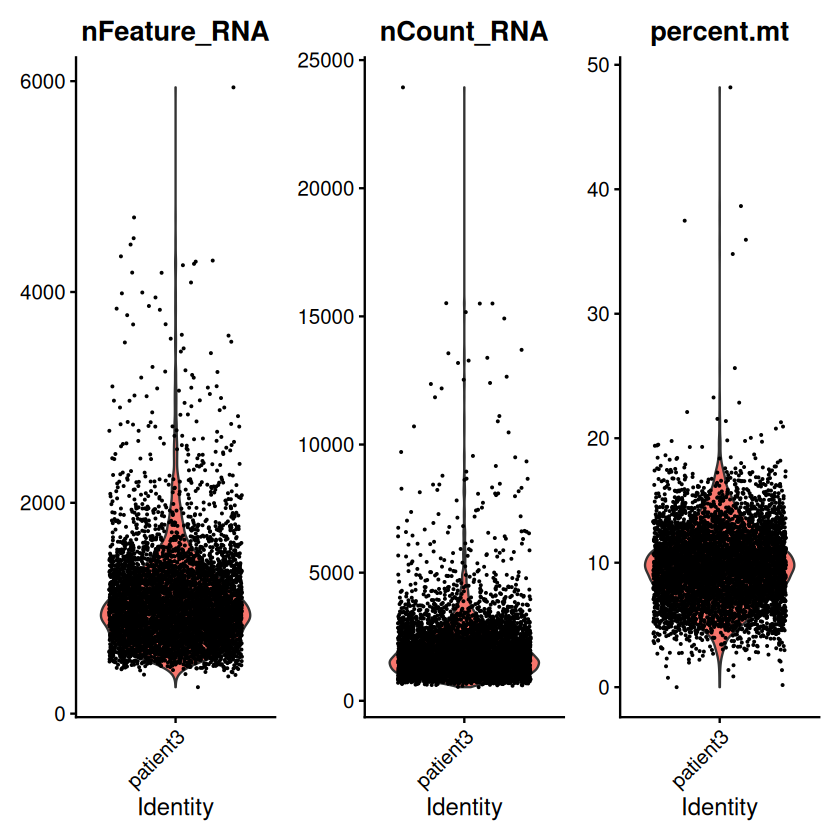

In [6]:
# Violin Plot
VlnPlot(patient3, features = c("nFeature_RNA", "nCount_RNA", "percent.mt"), ncol = 3)

In [7]:
# run sctransform
# this single command replaces NormalizeData(), ScaleData(), and FindVariableFeatures() #install glmGamPoi
patient3_transform <- SCTransform(patient3, verbose = FALSE) #No filtering based on mito. contamination

In [8]:
patient3_transform <- subset(patient3_transform, subset = percent.mt < 20)

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


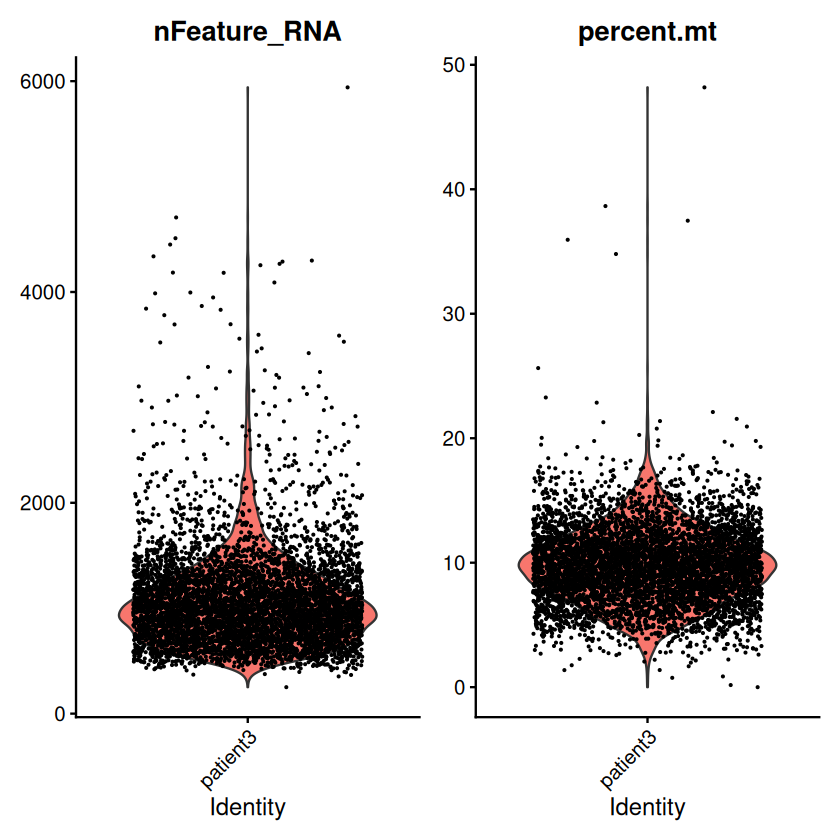

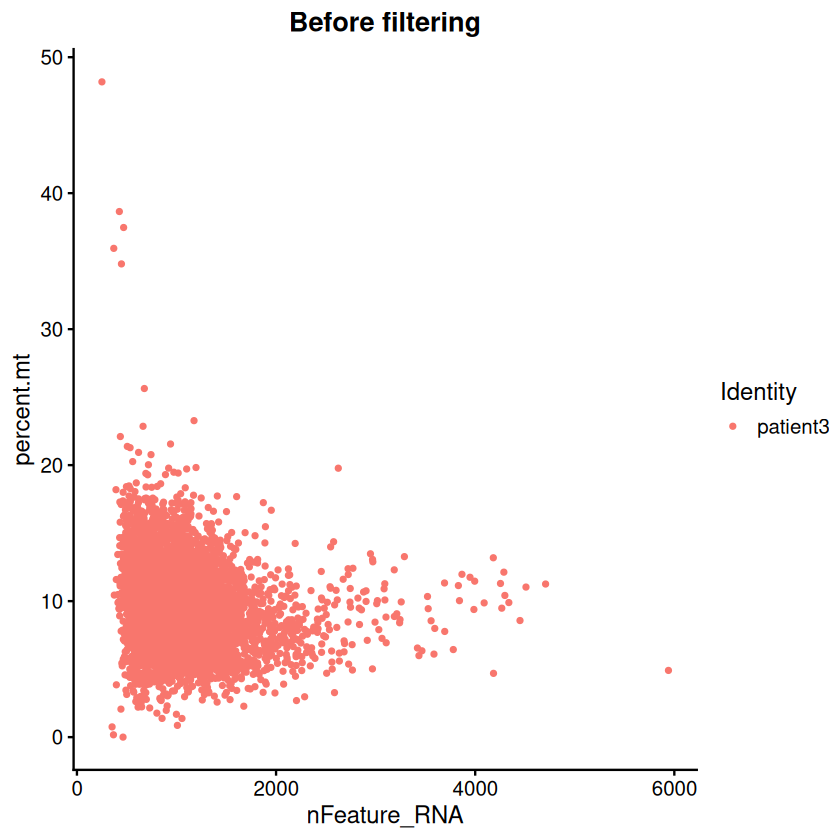

In [9]:
# before filtering
VlnPlot(patient3, features = c("nFeature_RNA", "percent.mt"), pt.size = 0.1)

FeatureScatter(patient3, feature1 = "nFeature_RNA", feature2 = "percent.mt") +
  ggtitle("Before filtering")

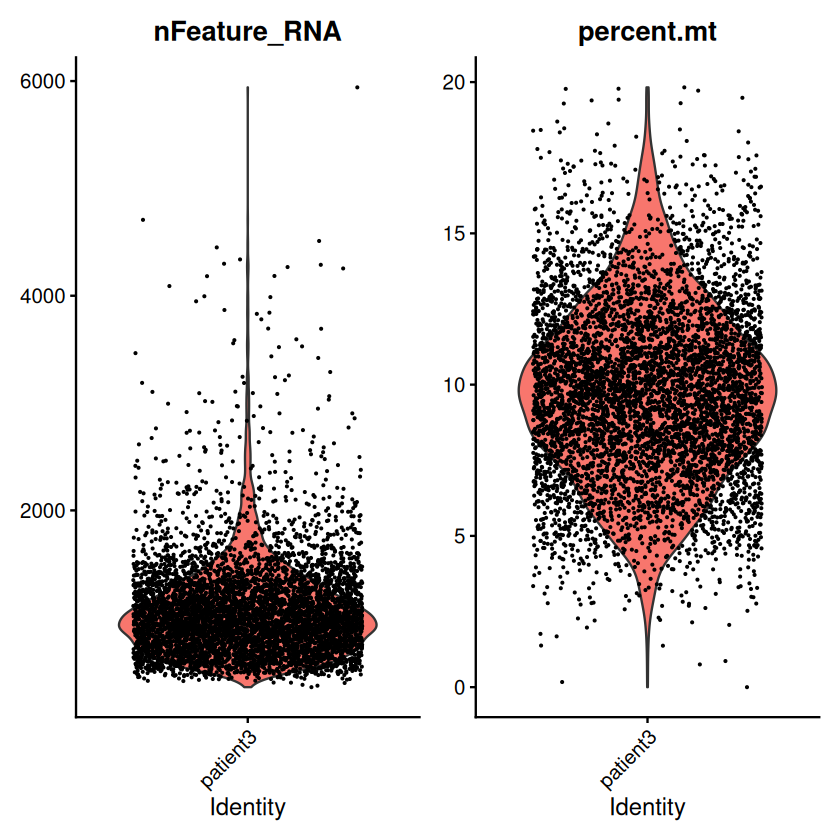

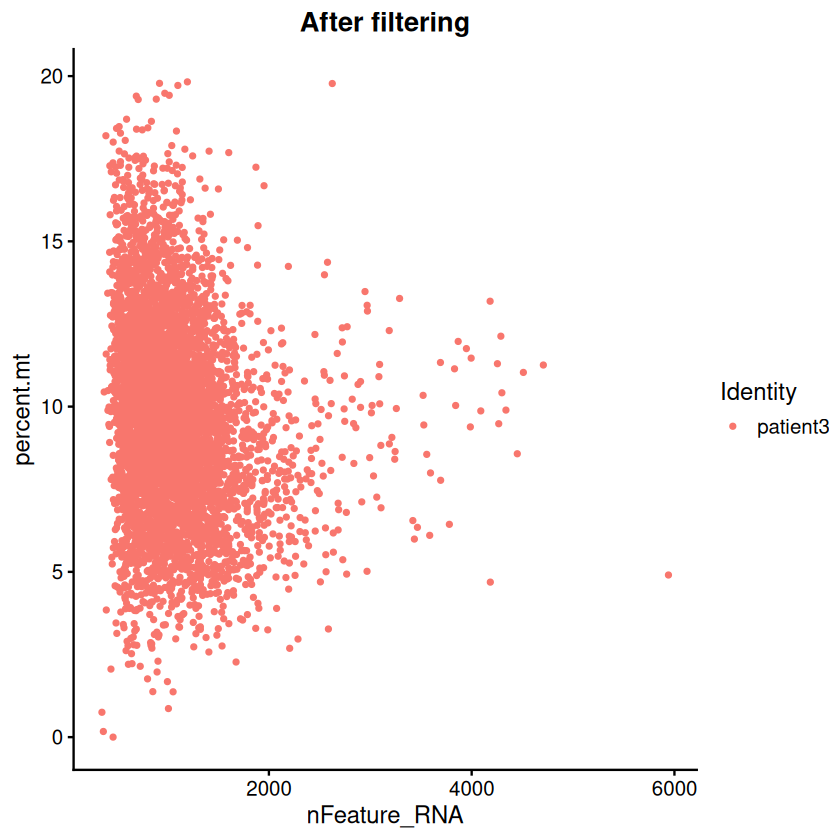

In [10]:
# after filtering
VlnPlot(patient3_transform, features = c("nFeature_RNA", "percent.mt"), pt.size = 0.1)

FeatureScatter(patient3_transform, feature1 = "nFeature_RNA", feature2 = "percent.mt") +
  ggtitle("After filtering")

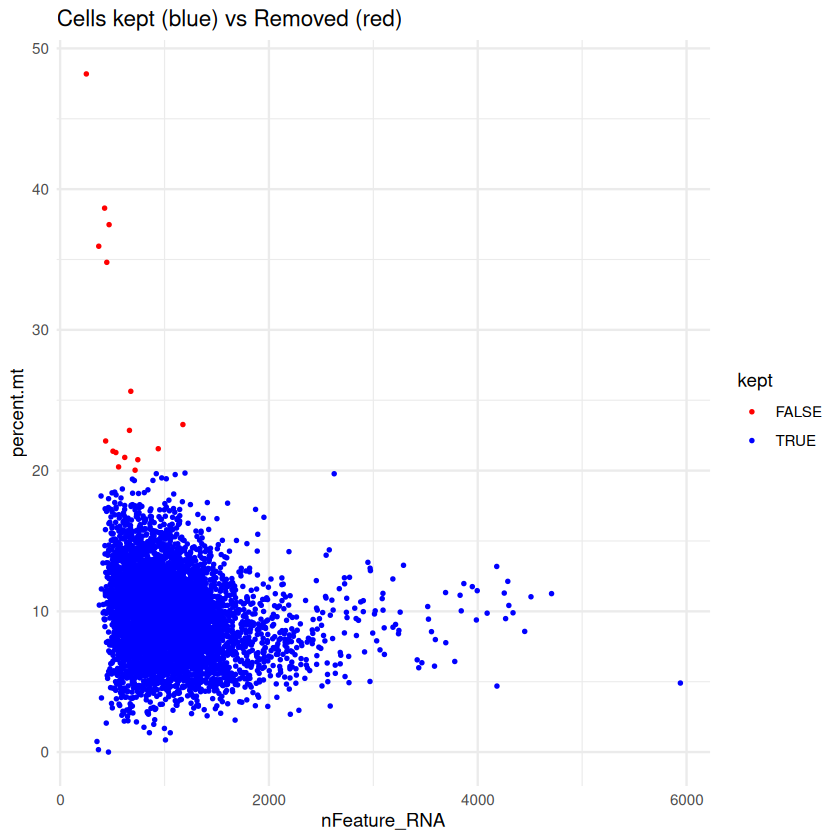

In [11]:
# Retained - Blue, Removed - Red
df <- FetchData(patient3, vars = c("nFeature_RNA", "percent.mt"))
df$kept <- rownames(df) %in% colnames(patient3_transform)

ggplot(df, aes(x = nFeature_RNA, y = percent.mt, color = kept)) +
  geom_point(size = 0.5) +
  scale_color_manual(values = c("red", "blue")) +
  theme_minimal() +
  labs(title = "Cells kept (blue) vs Removed (red)")

## 2. scRepertoire on patient 3

In [12]:
library(scRepertoire)
S1 <- read.delim("/home/rstudio/run070/run070-nsclc-3_VDJ_Dominant_Contigs_AIRR.tsv", sep = "\t", header = TRUE, stringsAsFactors = FALSE)

contig_list_1 <- list(S1)
contig_list_1 <- loadContigs(input = S1, 
                           format = "AIRR")

#converting columns in TCR data to character (string).
contig_list <- lapply(contig_list, function(df) {
  for (col in c("cdr3_nt", "cdr3", "chain", "barcode", "v_gene", "j_gene", "d_gene", "c_gene")) {
    if (col %in% names(df)) df[[col]] <- as.character(df[[col]])
  }
  df
})

In [13]:
data("contig_list")
#head(contig_list)
head(contig_list[[1]])

,barcode,is_cell,contig_id,high_confidence,length,chain,v_gene,d_gene,j_gene,c_gene,full_length,productive,cdr3,cdr3_nt,reads,umis,raw_clonotype_id,raw_consensus_id
,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<chr>
1,AAACCTGAGTACGACG-1,True,AAACCTGAGTACGACG-1_contig_1,True,500,TRA,TRAV25,None,TRAJ20,TRAC,True,True,CGCSNDYKLSF,TGTGGGTGTTCTAACGACTACAAGCTCAGCTTT,8344,4,clonotype123,clonotype123_consensus_2
2,AAACCTGAGTACGACG-1,True,AAACCTGAGTACGACG-1_contig_2,True,478,TRB,TRBV5-1,None,TRBJ2-7,TRBC2,True,True,CASSLTDRTYEQYF,TGCGCCAGCAGCTTGACCGACAGGACCTACGAGCAGTACTTC,65390,38,clonotype123,clonotype123_consensus_1
4,AAACCTGCAACACGCC-1,True,AAACCTGCAACACGCC-1_contig_1,True,506,TRA,TRAV38-2/DV8,None,TRAJ52,TRAC,True,True,CAYRSAQAGGTSYGKLTF,TGTGCTTATAGGAGCGCGCAGGCTGGTGGTACTAGCTATGGAAAGCTGACATTT,18372,8,clonotype124,clonotype124_consensus_1
5,AAACCTGCAACACGCC-1,True,AAACCTGCAACACGCC-1_contig_2,True,470,TRB,TRBV10-3,None,TRBJ2-2,TRBC2,True,True,CAISEQGKGELFF,TGTGCCATCAGTGAACAGGGGAAAGGGGAGCTGTTTTTT,34054,9,clonotype124,clonotype124_consensus_2
6,AAACCTGCAGGCGATA-1,True,AAACCTGCAGGCGATA-1_contig_1,True,558,TRA,TRAV12-1,None,TRAJ9,TRAC,True,True,CVVSDNTGGFKTIF,TGTGTGGTCTCCGATAATACTGGAGGCTTCAAAACTATCTTT,5018,2,clonotype1,clonotype1_consensus_2
7,AAACCTGCAGGCGATA-1,True,AAACCTGCAGGCGATA-1_contig_2,True,505,TRB,TRBV9,None,TRBJ2-2,TRBC2,True,True,CASSVRRERANTGELFF,TGTGCCAGCAGCGTAAGGAGGGAAAGGGCGAACACCGGGGAGCTGTTTTTT,25110,11,clonotype1,clonotype1_consensus_1


In [14]:
combined.TCR_p3 <- combineTCR(
  contig_list_1,
  samples = c("P3_S1"),
  removeNA = TRUE,
  removeMulti = FALSE,
  filterMulti = FALSE
)

# output = a list of contig data frames that will be reduced to the reads associated with a single cell barcode. It will also combine the multiple reads into clone calls by either the nucleotide sequence (CTnt), amino acid sequence (CTaa), the VDJC gene sequence (CTgene), or the combination of the nucleotide and gene sequence (CTstrict).
head(combined.TCR_p3[[1]])

,barcode,sample,TCR1,cdr3_aa1,cdr3_nt1,TCR2,cdr3_aa2,cdr3_nt2,CTgene,CTnt,CTaa,CTstrict
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,P3_S1_10006345,P3_S1,TRAV35*01.TRAJ18*01.TRAC,CAGPDRGSTLGRLYF,TGTGCTGGACCCGACAGAGGCTCAACCCTGGGGAGGCTATACTTT,TRBV20-1*01.TRBD2*01.TRBJ2-1*01.TRBC2,CSARGLGGSYNEQFF,TGCAGTGCTAGAGGATTGGGGGGGTCCTACAATGAGCAGTTCTTC,TRAV35*01.TRAJ18*01.TRAC_TRBV20-1*01.TRBD2*01.TRBJ2-1*01.TRBC2,TGTGCTGGACCCGACAGAGGCTCAACCCTGGGGAGGCTATACTTT_TGCAGTGCTAGAGGATTGGGGGGGTCCTACAATGAGCAGTTCTTC,CAGPDRGSTLGRLYF_CSARGLGGSYNEQFF,TRAV35*01.TRAJ18*01.TRAC;TGTGCTGGACCCGACAGAGGCTCAACCCTGGGGAGGCTATACTTT_TRBV20-1*01.TRBD2*01.TRBJ2-1*01.TRBC2;TGCAGTGCTAGAGGATTGGGGGGGTCCTACAATGAGCAGTTCTTC
3,P3_S1_10007655,P3_S1,TRAV17*01.TRAJ4*01.TRAC,CATDLFSGGYNKLIF,TGTGCTACGGATCTCTTTTCTGGTGGCTACAATAAGCTGATTTTT,TRBV6-6*01.TRBD2*01.TRBJ2-7*01.TRBC2,CASSQAGEQYF,TGTGCCAGCAGCCAGGCGGGCGAGCAGTACTTC,TRAV17*01.TRAJ4*01.TRAC_TRBV6-6*01.TRBD2*01.TRBJ2-7*01.TRBC2,TGTGCTACGGATCTCTTTTCTGGTGGCTACAATAAGCTGATTTTT_TGTGCCAGCAGCCAGGCGGGCGAGCAGTACTTC,CATDLFSGGYNKLIF_CASSQAGEQYF,TRAV17*01.TRAJ4*01.TRAC;TGTGCTACGGATCTCTTTTCTGGTGGCTACAATAAGCTGATTTTT_TRBV6-6*01.TRBD2*01.TRBJ2-7*01.TRBC2;TGTGCCAGCAGCCAGGCGGGCGAGCAGTACTTC
5,P3_S1_10024172,P3_S1,TRAV12-1*01.TRAJ42*01.TRAC,CVVNLAYYGGSQGNLIF,TGTGTGGTGAACCTTGCTTATTATGGAGGAAGCCAAGGAAATCTCATCTTT,TRBV9*01.NA.TRBJ1-5*01.TRBC1,CASSPGPSQPQHF,TGTGCCAGCAGCCCAGGACCGAGTCAGCCCCAGCATTTT,TRAV12-1*01.TRAJ42*01.TRAC_TRBV9*01.NA.TRBJ1-5*01.TRBC1,TGTGTGGTGAACCTTGCTTATTATGGAGGAAGCCAAGGAAATCTCATCTTT_TGTGCCAGCAGCCCAGGACCGAGTCAGCCCCAGCATTTT,CVVNLAYYGGSQGNLIF_CASSPGPSQPQHF,TRAV12-1*01.TRAJ42*01.TRAC;TGTGTGGTGAACCTTGCTTATTATGGAGGAAGCCAAGGAAATCTCATCTTT_TRBV9*01.NA.TRBJ1-5*01.TRBC1;TGTGCCAGCAGCCCAGGACCGAGTCAGCCCCAGCATTTT
7,P3_S1_10069653,P3_S1,TRAV3*01.TRAJ34*01.NA;TRGV2*01.TRGJP1*01.NA,CAVRGSIGTDKLIF;CATWDGFGWFKIF,TGTGCTGTGAGAGGTTCAATAGGAACCGACAAGCTCATCTTT;TGTGCCACCTGGGACGGGTTCGGTTGGTTCAAGATATTT,TRDV3*01.TRDD3*01.TRDJ1*01.TRDC,CAFNRNWGIHSDKLIF,TGTGCCTTTAATCGAAACTGGGGGATACATTCCGATAAACTCATCTTT,TRAV3*01.TRAJ34*01.NA;TRGV2*01.TRGJP1*01.NA_TRDV3*01.TRDD3*01.TRDJ1*01.TRDC,TGTGCTGTGAGAGGTTCAATAGGAACCGACAAGCTCATCTTT;TGTGCCACCTGGGACGGGTTCGGTTGGTTCAAGATATTT_TGTGCCTTTAATCGAAACTGGGGGATACATTCCGATAAACTCATCTTT,CAVRGSIGTDKLIF;CATWDGFGWFKIF_CAFNRNWGIHSDKLIF,TRAV3*01.TRAJ34*01.NA;TRGV2*01.TRGJP1*01.NA;TGTGCTGTGAGAGGTTCAATAGGAACCGACAAGCTCATCTTT;TGTGCCACCTGGGACGGGTTCGGTTGGTTCAAGATATTT_TRDV3*01.TRDD3*01.TRDJ1*01.TRDC;TGTGCCTTTAATCGAAACTGGGGGATACATTCCGATAAACTCATCTTT
10,P3_S1_10075139,P3_S1,TRAV19*01.TRAJ6*01.TRAC,CALSGRSGGSYIPTF,TGTGCTCTGAGTGGTAGATCAGGAGGAAGCTACATACCTACATTT,TRBV7-9*03.NA.TRBJ1-1*01.TRBC1,CASSFADSTTEAFF,TGTGCCAGCAGCTTTGCCGATTCTACCACTGAAGCTTTCTTT,TRAV19*01.TRAJ6*01.TRAC_TRBV7-9*03.NA.TRBJ1-1*01.TRBC1,TGTGCTCTGAGTGGTAGATCAGGAGGAAGCTACATACCTACATTT_TGTGCCAGCAGCTTTGCCGATTCTACCACTGAAGCTTTCTTT,CALSGRSGGSYIPTF_CASSFADSTTEAFF,TRAV19*01.TRAJ6*01.TRAC;TGTGCTCTGAGTGGTAGATCAGGAGGAAGCTACATACCTACATTT_TRBV7-9*03.NA.TRBJ1-1*01.TRBC1;TGTGCCAGCAGCTTTGCCGATTCTACCACTGAAGCTTTCTTT
12,P3_S1_10088479,P3_S1,TRAV13-1*01.TRAJ54*01.TRAC,CAASMVGAQKLVF,TGTGCAGCAAGTATGGTTGGAGCCCAGAAGCTGGTATTT,TRBV28*01.TRBD1*01.TRBJ2-7*01.TRBC2,CASSLSLGASYEQYF,TGTGCCAGCAGTTTATCTTTGGGGGCCTCCTACGAGCAGTACTTC,TRAV13-1*01.TRAJ54*01.TRAC_TRBV28*01.TRBD1*01.TRBJ2-7*01.TRBC2,TGTGCAGCAAGTATGGTTGGAGCCCAGAAGCTGGTATTT_TGTGCCAGCAGTTTATCTTTGGGGGCCTCCTACGAGCAGTACTTC,CAASMVGAQKLVF_CASSLSLGASYEQYF,TRAV13-1*01.TRAJ54*01.TRAC;TGTGCAGCAAGTATGGTTGGAGCCCAGAAGCTGGTATTT_TRBV28*01.TRBD1*01.TRBJ2-7*01.TRBC2;TGTGCCAGCAGTTTATCTTTGGGGGCCTCCTACGAGCAGTACTTC


### Visualization

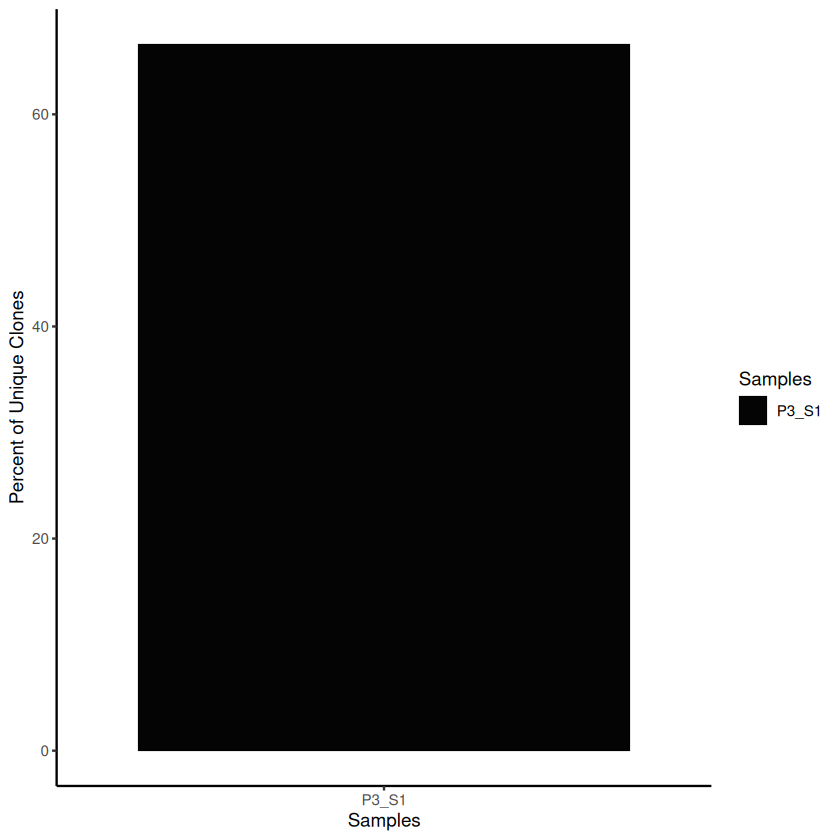

In [15]:
# total or relative numbers of unique clones.
clonalQuant(combined.TCR_p3, 
            cloneCall="strict", 
            chain = "both", 
            scale = TRUE)

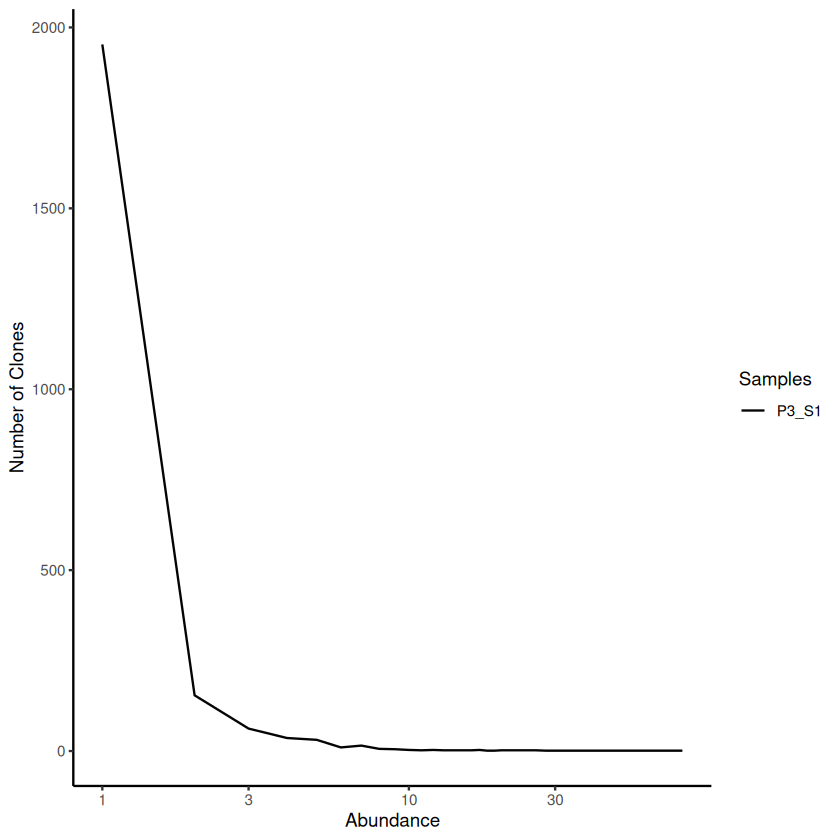

In [16]:
# a total number of clones by the number of instances within the sample or run
clonalAbundance(combined.TCR_p3, 
                cloneCall = "gene", 
                scale = FALSE)

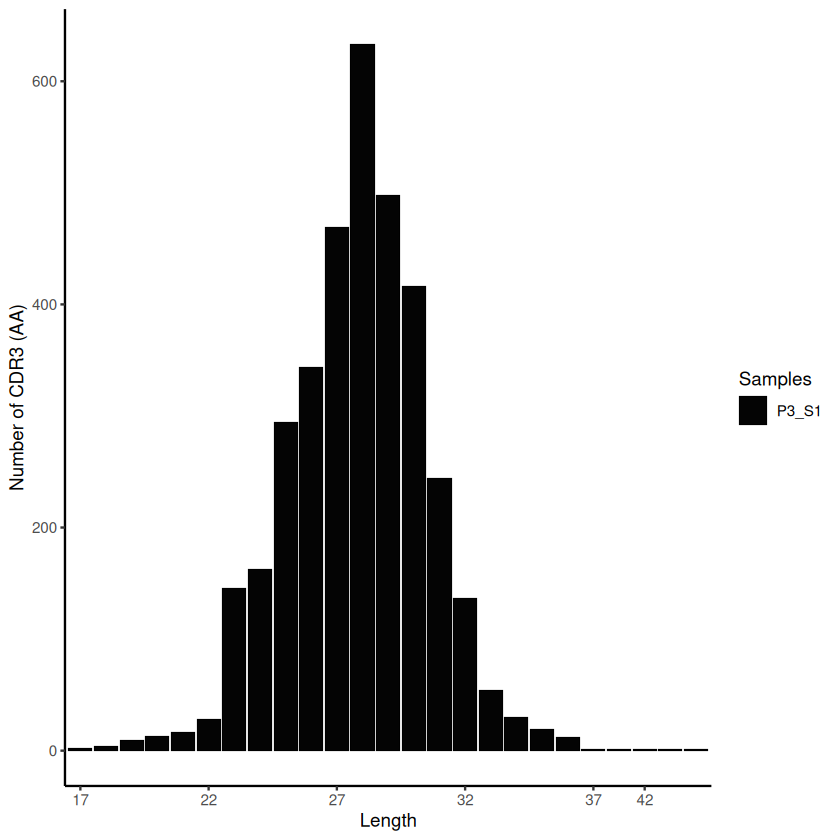

In [17]:
clonalLength(combined.TCR_p3, 
             cloneCall="aa", 
             chain = "both") 

## 3. Seurat using sctransform on patient 4

In [18]:
patient4.data <- Read10X(data.dir = "/home/rstudio/run071/run071_RSEC_MolsPerCell_MEX")
patient4 <- CreateSeuratObject(counts = patient4.data, project = "patient4", min.cells = 3, min.features = 200)

In [19]:
#QC #calculates the percentage of counts originating from a set of features #mitochondrial contamination
patient4[["percent.mt"]] <- PercentageFeatureSet(patient4, pattern = "^MT-")

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


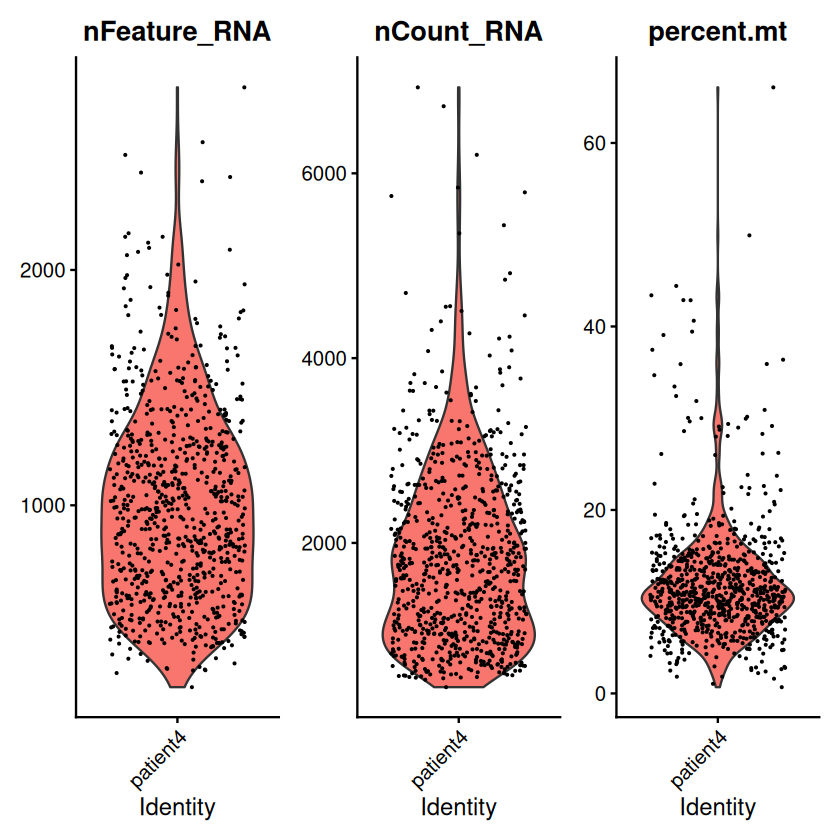

In [20]:
# Violin Plot
VlnPlot(patient4, features = c("nFeature_RNA", "nCount_RNA", "percent.mt"), ncol = 3)

In [21]:
# run sctransform
# this single command replaces NormalizeData(), ScaleData(), and FindVariableFeatures() #install glmGamPoi
patient4_transform <- SCTransform(patient4, verbose = FALSE) #No filtering based on mito. contamination

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


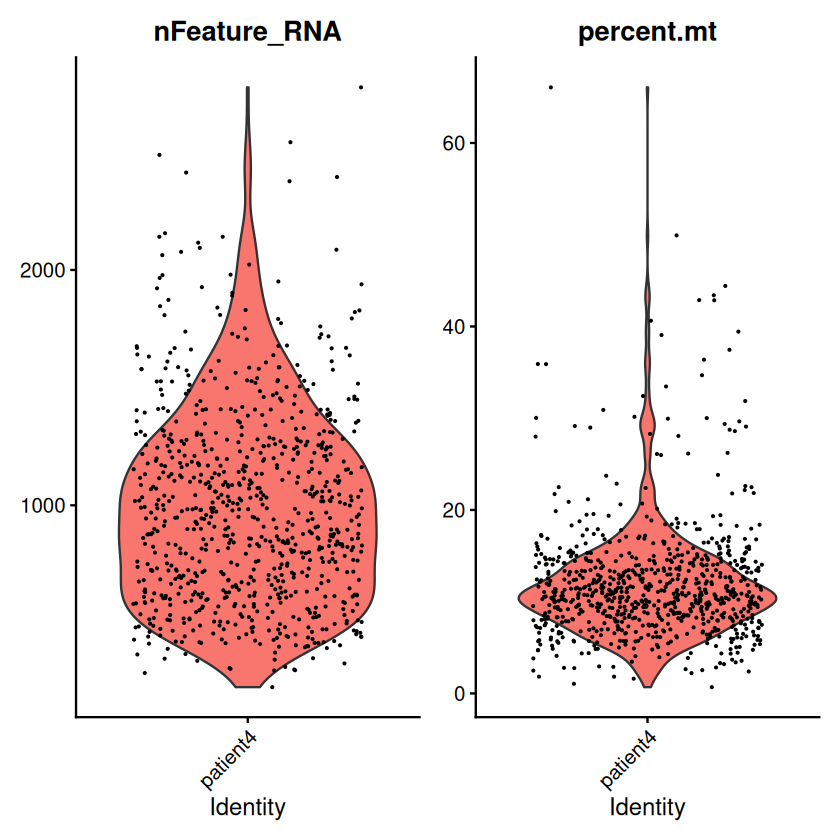

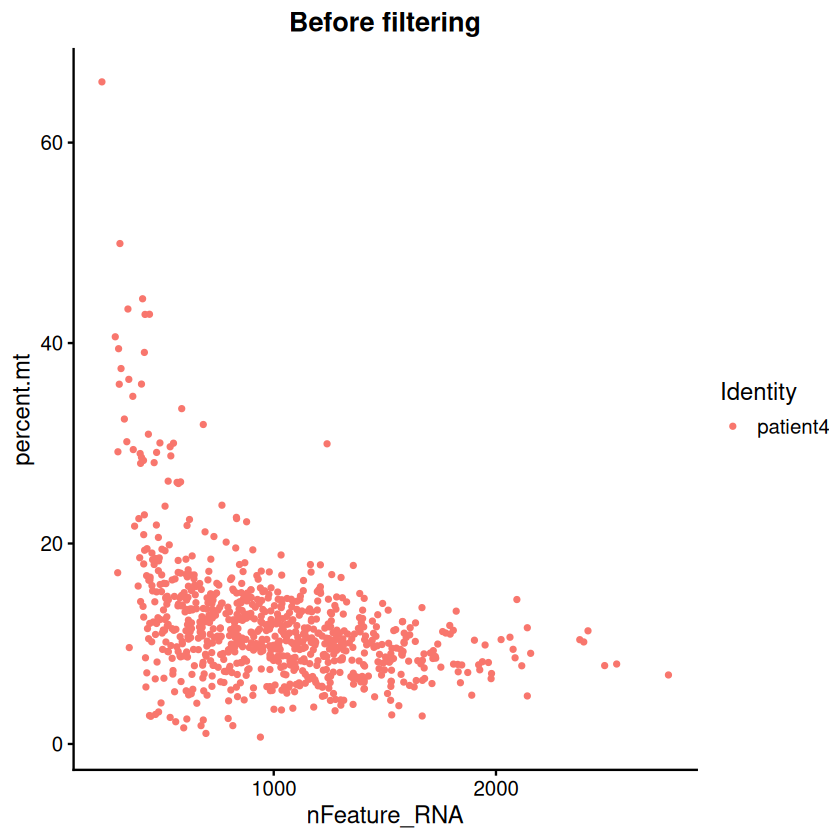

In [22]:
# before filtering
VlnPlot(patient4, features = c("nFeature_RNA", "percent.mt"), pt.size = 0.1)

FeatureScatter(patient4, feature1 = "nFeature_RNA", feature2 = "percent.mt") +
  ggtitle("Before filtering")

In [23]:
patient4_transform <- subset(patient4_transform, subset = percent.mt < 20) 

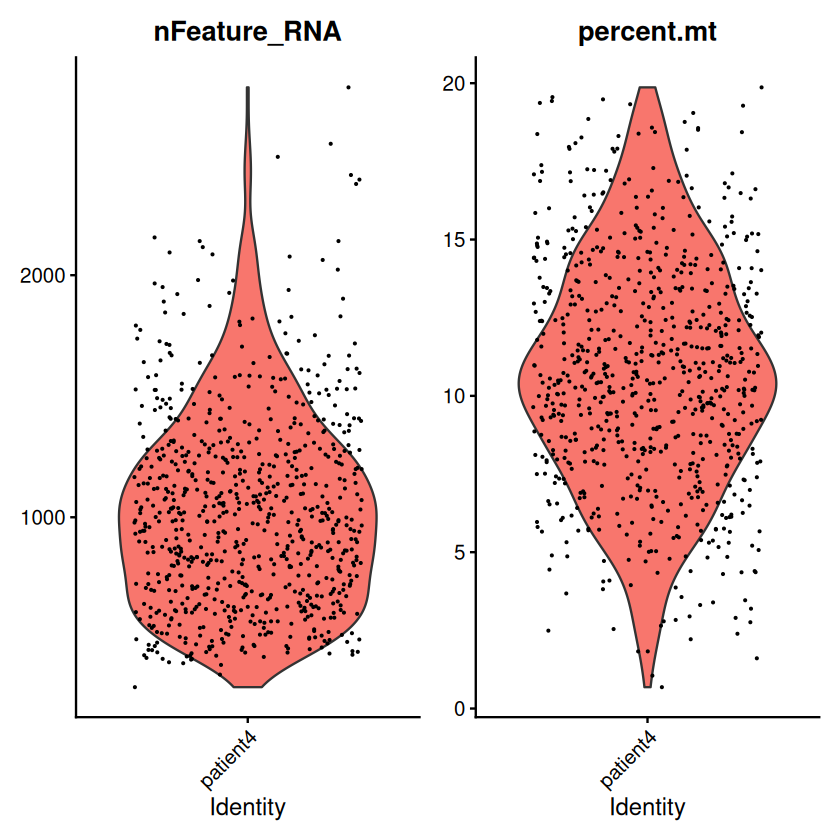

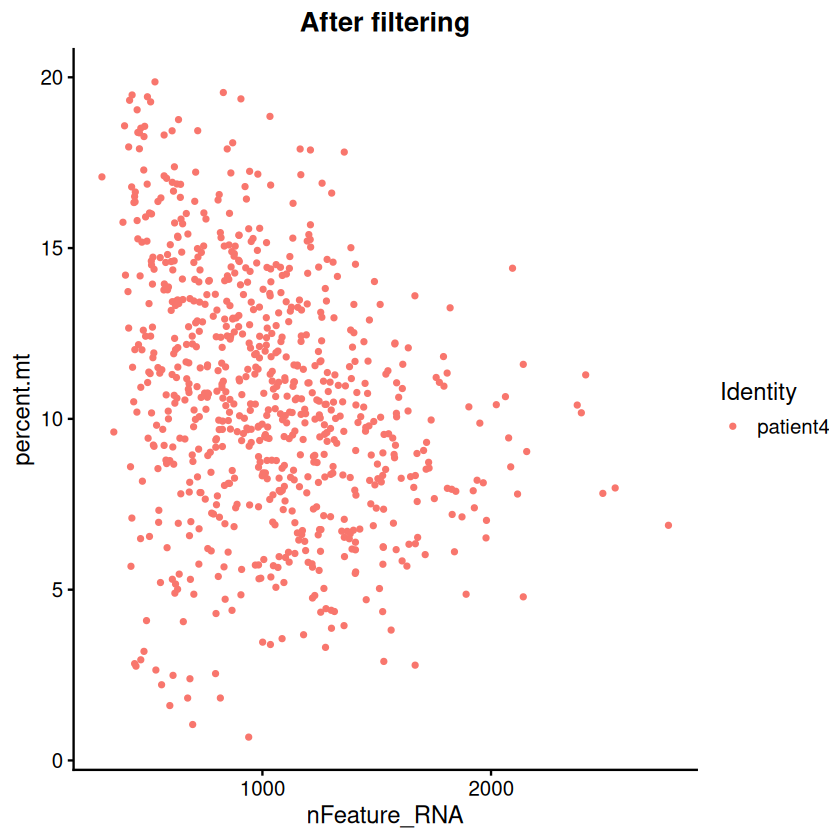

In [24]:
# after filtering
VlnPlot(patient4_transform, features = c("nFeature_RNA", "percent.mt"), pt.size = 0.1)

FeatureScatter(patient4_transform, feature1 = "nFeature_RNA", feature2 = "percent.mt") +
  ggtitle("After filtering")

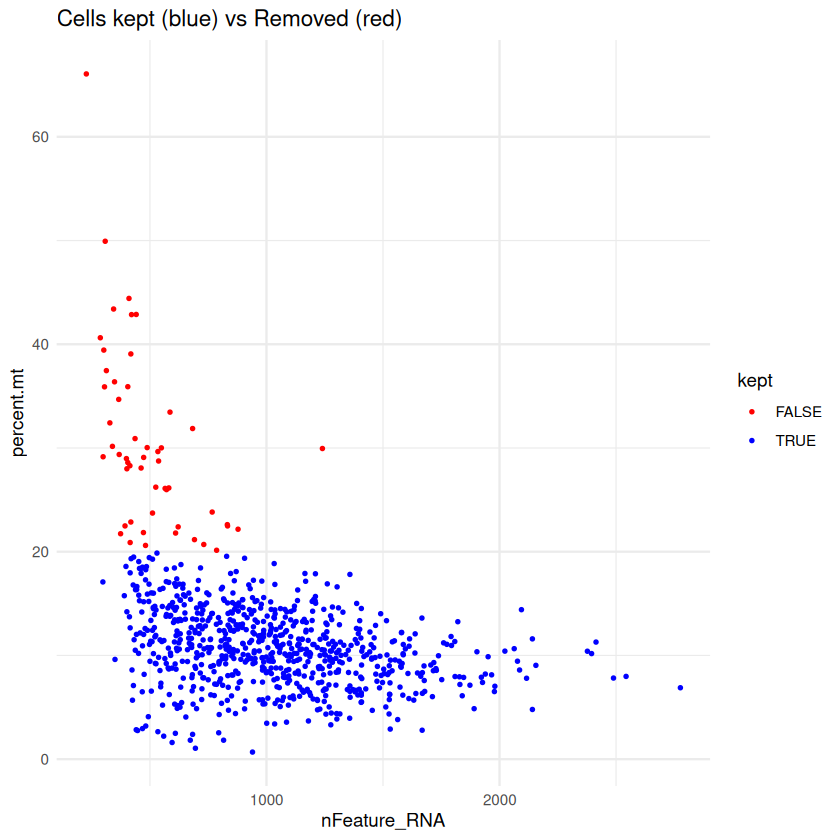

In [25]:
# Retained - Blue, Removed - Red
df <- FetchData(patient4, vars = c("nFeature_RNA", "percent.mt"))
df$kept <- rownames(df) %in% colnames(patient4_transform)

ggplot(df, aes(x = nFeature_RNA, y = percent.mt, color = kept)) +
  geom_point(size = 0.5) +
  scale_color_manual(values = c("red", "blue")) +
  theme_minimal() +
  labs(title = "Cells kept (blue) vs Removed (red)")

## 4. scRepertoire on patient 4

In [26]:
library(scRepertoire)
#S1 <- read.delim("/home/rstudio/run071-nsclc-4_VDJ_Dominant_Contigs_AIRR.tsv", sep = "\t", header = TRUE, stringsAsFactors = FALSE)

#contig_list <- list(S1)
#contig.list <- loadContigs(input = S1, 
#                           format = "AIRR")

In [27]:
library(scRepertoire)
S2 <- read.delim("/home/rstudio/run071/run071-nsclc-4_VDJ_Dominant_Contigs_AIRR.tsv", sep = "\t", header = TRUE, stringsAsFactors = FALSE)

contig_list_2 <- list(S2)
contig_list_2 <- loadContigs(input = S2, 
                           format = "AIRR")

#converting columns in TCR data to character (string).
contig_list <- lapply(contig_list, function(df) {
  for (col in c("cdr3_nt", "cdr3", "chain", "barcode", "v_gene", "j_gene", "d_gene", "c_gene")) {
    if (col %in% names(df)) df[[col]] <- as.character(df[[col]])
  }
  df
})

In [28]:
#data("contig_list")
#head(contig_list)
head(contig_list_2[[1]])

,barcode,chain,reads,v_gene,d_gene,j_gene,c_gene,cdr3_nt,cdr3
,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
190,11226389,TRA,1,TRAV21*01,,TRAJ18*01,IGHA1,TGTGCTGTTGATAGCGGCAGAGGCTCAACCCTGGGGGTA,CAVDSGRGSTLGV
386,22733773,TRA,1,TRAV38-2/DV8*01,,TRAJ30*01,,TGTGCTAGCAGATGACAAGATCATCTTT,CASR*QDHL
835,44116358,TRB,1,TRBV28*01,TRBD2*01,TRBJ2-7*01,TRBC2,TGTGCCAGCAGTTTATGGCGGCGGGGCGAGCAGCACTTC,CASSLWRRGEQHF
64,3784046,TRA,2,TRAV21*01,,TRAJ18*01,,TGTGCTGTTGATAGCGGCAGAGGCTCAACCCTGGGGAGGCAAG,CAVDSGRGSTLGRQ
161,9653855,TRA,2,TRAV1-1*01,,TRAJ31*01,,TGCGCTGTGAACAACAATGCCAGACTCAAGA,CAVNNNARLK
327,19483736,TRA,2,TRAV21*01,,TRAJ18*01,,TGTGCTGTTGATAGCGGCAGAGGCTCAACCCGGGGGAGGC,CAVDSGRGSTRGR


In [29]:
combined.TCR_p4 <- combineTCR(
  contig_list_2,
  samples = c("P4_S1"),
  removeNA = TRUE,
  removeMulti = FALSE,
  filterMulti = FALSE
)

# output = a list of contig data frames that will be reduced to the reads associated with a single cell barcode. It will also combine the multiple reads into clone calls by either the nucleotide sequence (CTnt), amino acid sequence (CTaa), the VDJC gene sequence (CTgene), or the combination of the nucleotide and gene sequence (CTstrict).
#check
head(combined.TCR_p4[[1]])

,barcode,sample,TCR1,cdr3_aa1,cdr3_nt1,TCR2,cdr3_aa2,cdr3_nt2,CTgene,CTnt,CTaa,CTstrict
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,P4_S1_1002101,P4_S1,TRAV19*01.TRAJ27*01.TRAC,CAPTPMQANQP,TGTGCCCCAACACCAATGCAGGCAAATCAACCTTT,TRBV11-2*01.NA.TRBJ1-1*01.TRBC1,CASSLHPVKGWEAFF,TGTGCCAGCAGCTTACATCCGGTTAAAGGATGGGAAGCTTTCTTT,TRAV19*01.TRAJ27*01.TRAC_TRBV11-2*01.NA.TRBJ1-1*01.TRBC1,TGTGCCCCAACACCAATGCAGGCAAATCAACCTTT_TGTGCCAGCAGCTTACATCCGGTTAAAGGATGGGAAGCTTTCTTT,CAPTPMQANQP_CASSLHPVKGWEAFF,TRAV19*01.TRAJ27*01.TRAC;TGTGCCCCAACACCAATGCAGGCAAATCAACCTTT_TRBV11-2*01.NA.TRBJ1-1*01.TRBC1;TGTGCCAGCAGCTTACATCCGGTTAAAGGATGGGAAGCTTTCTTT
3,P4_S1_10279593,P4_S1,TRAV13-2*01.TRAJ26*01.TRAC,CAENTRGRRSEFCL,TGTGCAGAGAATACGAGGGGTAGGAGGTCAGAATTTTGTCTTT,TRBV6-2*01.TRBD1*01.TRBJ1-1*01.TRBC1,CASEPGGDLAEAFF,TGTGCCAGCGAACCCGGGGGCGATTTGGCTGAAGCTTTCTTT,TRAV13-2*01.TRAJ26*01.TRAC_TRBV6-2*01.TRBD1*01.TRBJ1-1*01.TRBC1,TGTGCAGAGAATACGAGGGGTAGGAGGTCAGAATTTTGTCTTT_TGTGCCAGCGAACCCGGGGGCGATTTGGCTGAAGCTTTCTTT,CAENTRGRRSEFCL_CASEPGGDLAEAFF,TRAV13-2*01.TRAJ26*01.TRAC;TGTGCAGAGAATACGAGGGGTAGGAGGTCAGAATTTTGTCTTT_TRBV6-2*01.TRBD1*01.TRBJ1-1*01.TRBC1;TGTGCCAGCGAACCCGGGGGCGATTTGGCTGAAGCTTTCTTT
6,P4_S1_10311423,P4_S1,TRAV21*01.TRAJ15*01.TRAC,CAVVNQAGTALIF,TGTGCTGTAGTTAACCAGGCAGGAACTGCTCTGATCTTT,TRBV11-2*01.TRBD2*02.TRBJ1-2*01.TRBC1,CASSPYPGGGYTF,TGTGCCAGCAGCCCATACCCGGGAGGAGGCTACACCTTC,TRAV21*01.TRAJ15*01.TRAC_TRBV11-2*01.TRBD2*02.TRBJ1-2*01.TRBC1,TGTGCTGTAGTTAACCAGGCAGGAACTGCTCTGATCTTT_TGTGCCAGCAGCCCATACCCGGGAGGAGGCTACACCTTC,CAVVNQAGTALIF_CASSPYPGGGYTF,TRAV21*01.TRAJ15*01.TRAC;TGTGCTGTAGTTAACCAGGCAGGAACTGCTCTGATCTTT_TRBV11-2*01.TRBD2*02.TRBJ1-2*01.TRBC1;TGTGCCAGCAGCCCATACCCGGGAGGAGGCTACACCTTC
8,P4_S1_10627379,P4_S1,TRAV29/DV5*01.TRAJ47*01.TRAC,CAASRYGNKLVF,TGTGCAGCAAGCAGATATGGAAACAAACTGGTCTTT,TRBV27*01.TRBD2*02.TRBJ2-2*01.TRBC2,CASNFQLAGVGGELFF,TGTGCCAGCAACTTCCAACTAGCGGGAGTTGGCGGGGAGCTGTTTTTT,TRAV29/DV5*01.TRAJ47*01.TRAC_TRBV27*01.TRBD2*02.TRBJ2-2*01.TRBC2,TGTGCAGCAAGCAGATATGGAAACAAACTGGTCTTT_TGTGCCAGCAACTTCCAACTAGCGGGAGTTGGCGGGGAGCTGTTTTTT,CAASRYGNKLVF_CASNFQLAGVGGELFF,TRAV29/DV5*01.TRAJ47*01.TRAC;TGTGCAGCAAGCAGATATGGAAACAAACTGGTCTTT_TRBV27*01.TRBD2*02.TRBJ2-2*01.TRBC2;TGTGCCAGCAACTTCCAACTAGCGGGAGTTGGCGGGGAGCTGTTTTTT
10,P4_S1_10742731,P4_S1,TRAV9-2*01.TRAJ43*01.TRAC,CALGEGDMRF,TGTGCTCTGGGGGAGGGTGACATGCGCTTT,TRBV11-2*01.TRBD1*01.TRBJ2-7*01.TRBC2,CASSRGARVAAYEQYF,TGTGCCAGCAGCCGAGGGGCGAGGGTGGCCGCCTACGAGCAGTACTTC,TRAV9-2*01.TRAJ43*01.TRAC_TRBV11-2*01.TRBD1*01.TRBJ2-7*01.TRBC2,TGTGCTCTGGGGGAGGGTGACATGCGCTTT_TGTGCCAGCAGCCGAGGGGCGAGGGTGGCCGCCTACGAGCAGTACTTC,CALGEGDMRF_CASSRGARVAAYEQYF,TRAV9-2*01.TRAJ43*01.TRAC;TGTGCTCTGGGGGAGGGTGACATGCGCTTT_TRBV11-2*01.TRBD1*01.TRBJ2-7*01.TRBC2;TGTGCCAGCAGCCGAGGGGCGAGGGTGGCCGCCTACGAGCAGTACTTC
13,P4_S1_10800031,P4_S1,TRAV14/DV4*01.TRAJ29*01.TRAC,CAMREGPGNTPLVF,TGTGCAATGAGAGAGGGCCCAGGAAACACACCTCTTGTCTTT,TRBV20-1*01.TRBD1*01.TRBJ2-7*01.TRBC2,CSVDRAYEQYF,TGCAGTGTTGACAGGGCCTACGAGCAGTACTTC,TRAV14/DV4*01.TRAJ29*01.TRAC_TRBV20-1*01.TRBD1*01.TRBJ2-7*01.TRBC2,TGTGCAATGAGAGAGGGCCCAGGAAACACACCTCTTGTCTTT_TGCAGTGTTGACAGGGCCTACGAGCAGTACTTC,CAMREGPGNTPLVF_CSVDRAYEQYF,TRAV14/DV4*01.TRAJ29*01.TRAC;TGTGCAATGAGAGAGGGCCCAGGAAACACACCTCTTGTCTTT_TRBV20-1*01.TRBD1*01.TRBJ2-7*01.TRBC2;TGCAGTGTTGACAGGGCCTACGAGCAGTACTTC


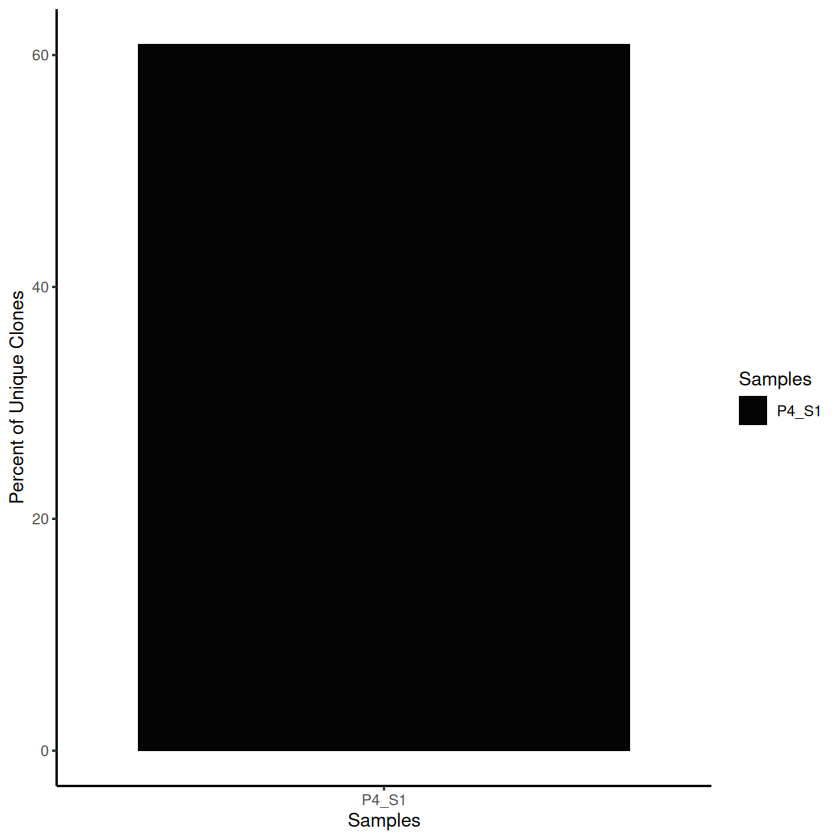

In [30]:
# total or relative numbers of unique clones.
clonalQuant(combined.TCR_p4, 
            cloneCall="strict", 
            chain = "both", 
            scale = TRUE)

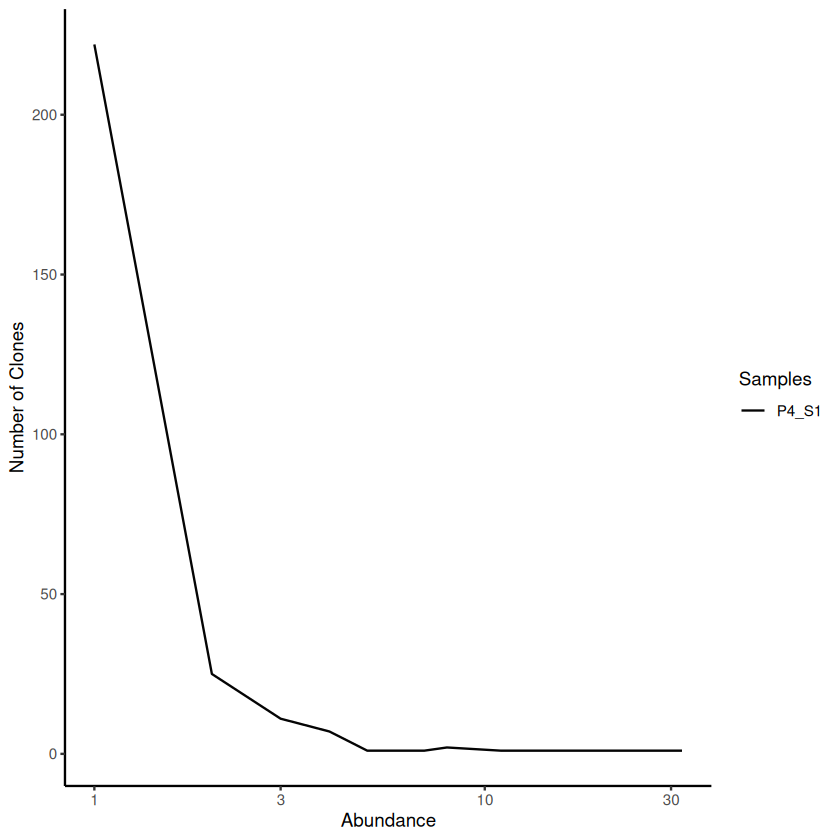

In [31]:
# a total number of clones by the number of instances within the sample or run
clonalAbundance(combined.TCR_p4, 
                cloneCall = "gene", 
                scale = FALSE)

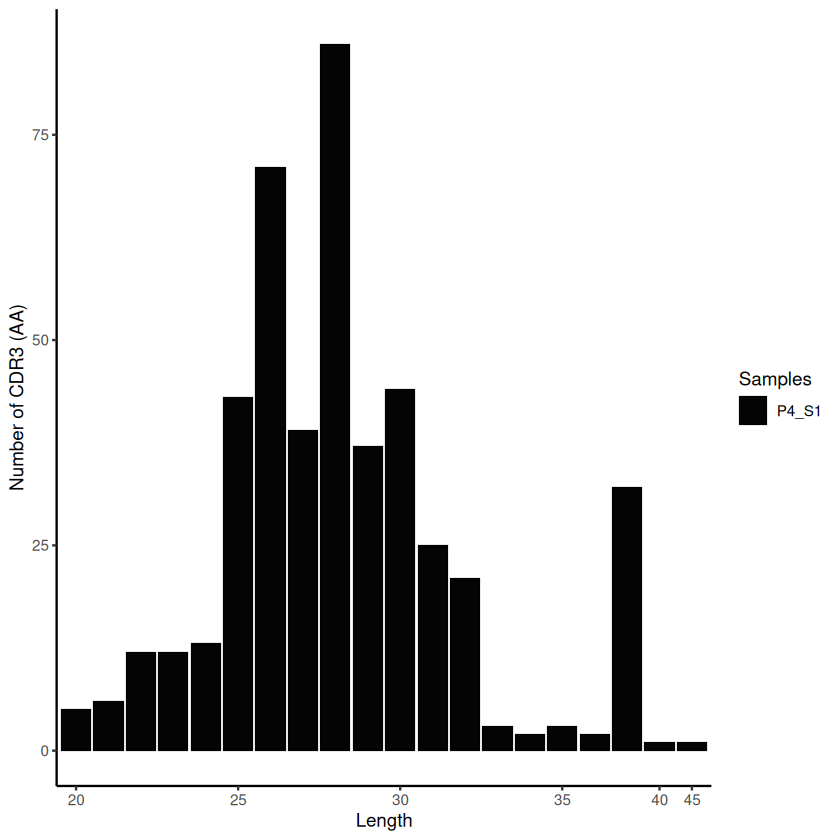

In [32]:
clonalLength(combined.TCR_p4, 
             cloneCall="aa", 
             chain = "both") 

In [33]:
sapply(contig_list_1, nrow)
sapply(contig_list_2, nrow)

[1] 8871

[1] 1104

## 5. Seurat using sctransform and RPCA integration on patients 3 and 4

In [34]:
# load in the pbmc systematic comparative analysis dataset
#obj <- LoadData("pbmcsca")
#obj <- subset(obj, nFeature_RNA > 1000)
#obj <- RunAzimuth(obj, reference = "pbmcref")
# currently, the object has two layers in the RNA assay: counts, and data
#obj


### Using integratelayers()

In [35]:
#patient3_transform

In [36]:
#patient3_transform@version
#patient4_transform@version

In [37]:
#DefaultAssay(patient3_transform) <- "RNA"
#DefaultAssay(patient4_transform) <- "RNA"

In [38]:
merged_seurat <- merge(patient3_transform, patient4_transform)

In [39]:
install.packages('BiocManager')
BiocManager::install('glmGamPoi')

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://p3m.dev/cran/__linux__/noble/2025-02-27

Bioconductor version 3.20 (BiocManager 1.30.25), R 4.4.2 (2024-10-31)

Warning message:
“package(s) not installed when version(s) same as or greater than current; use
  `force = TRUE` to re-install: 'glmGamPoi'”
Old packages: 'BiocParallel', 'curl', 'data.table', 'DOSE', 'ggnewscale',
  'jsonlite', 'processx', 'ps', 'R.utils', 'reticulate', 'tinytex', 'uwot',
  'VGAM', 'xfun', 'zoo'



In [40]:
merged_seurat <- SCTransform(merged_seurat, verbose = FALSE)

Warning message:
“Different cells and/or features from existing assay SCT”


In [41]:
merged_seurat <- RunPCA(merged_seurat, npcs = 35)

Warning message in PrepDR(object = object, features = features, verbose = verbose):
“The following 28 features requested have not been scaled (running reduction without them): CXCL8, LYZ, IL1B, CXCL2, FCN1, MARCKS, CXCL3, SERPINB2, S100A8, EREG, G0S2, KIR2DL1, MAFB, LILRB2, CYBB, KRT72, KIR2DS4, PPP1R2C, SERPINA1, ZBED3, XIST, TRDC, FPR1, DDX3Y, PLS3, TNFAIP2, MPEG1, SPI1”
PC_ 1 
Positive:  FTH1, EEF1A1, IL7R, PABPC1, RPL34, RPS6, TPT1, RPS18, RPS12, SELL 
	   RPS27, RPL21, RPS29, ANXA1, RPL3, RPS3A, RPS13, RPL32, RPS20, RPS8 
	   RPL39, KLF2, MT-ND2, RPS23, RPL13A, RPS27A, RPL9, RPL31, RPL10, RPS4X 
Negative:  DUSP4, HSPA1A, CXCL13, HLA-DRB1, CCL5, CD74, HSP90AA1, RBPJ, RGS1, PMAIP1 
	   CRTAM, MYO7A, CCL4, HLA-DRA, HSPA1B, GZMB, NKG7, PRDM1, ITGAE, CBLB 
	   TNFRSF9, VCAM1, KRT86, LYST, GLCCI1, CTLA4, TOX, HLA-DRB6, TUBB, IKZF3 
PC_ 2 
Positive:  TUBB, TYMS, STMN1, ACTB, RRM2, TUBA1B, HMGN2, MKI67, TOP2A, VIM 
	   HMGB2, ACTG1, HSPA1A, ASPM, CENPU, HLA-DRA, SMC4, PCNA, CCNA2, HSPA1B 

In [42]:
merged_seurat

An object of class Seurat 
45180 features across 6489 samples within 2 assays 
Active assay: SCT (21306 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 1 other assay present: RNA
 1 dimensional reduction calculated: pca

In [43]:
merged_seurat <- FindVariableFeatures(merged_seurat, assay = "RNA")

Finding variable features for layer counts.patient3

Finding variable features for layer counts.patient4



In [44]:
merged_seurat <- NormalizeData(merged_seurat, assay = "RNA")

Normalizing layer: counts.patient3

Normalizing layer: counts.patient4



In [45]:
merged_seurat <- ScaleData(merged_seurat, assay = "RNA")

Centering and scaling data matrix



In [46]:
DefaultAssay(merged_seurat) <- "RNA"

In [47]:
merged_seurat <- RunPCA(merged_seurat, assay = "RNA", reduction.name = "pca.rna")

PC_ 1 
Positive:  IL7R, KLF2, FTH1, SELL, SATB1, ANXA1, FOS, S1PR1, SESN3, LNCRNA-IUR 
	   MT-CO3, RPS2, YBX3, ZBTB16, SNED1, RPS18, GPCPD1, IRS2, GPR183, KRT1 
	   RNF130, ACTN1, BACH2, ARL4C, MBP, KCNA3, ABLIM1, ZHX2, SCML1, MT-CO1 
Negative:  TYMS, DUSP4, MKI67, HLA-DRB1, RRM2, TOP2A, CXCL13, HLA-DRA, NCAPG, CENPU 
	   MYO7A, RBPJ, ASPM, TPX2, KIF11, CCNA2, ITGAE, GZMB, STMN1, CDK1 
	   CTLA4, HLA-DRB6, APOBEC3C, UBE2C, CD74, HSPA1A, HMGB2, CCL5, PMAIP1, NKG7 
PC_ 2 
Positive:  DUSP4, CCL5, MYO7A, TNFRSF9, CBLB, ITGAE, LYST, NKG7, CXCL13, KRT86 
	   AKAP5, LAYN, RGS1, HSPA1A, ETV1, PRDM1, VCAM1, RBPJ, CXCR6, GZMB 
	   CTLA4, HAVCR2, ADGRG1, TOX, HLA-DRB1, IKZF3, PRF1, RDH10, GOLIM4, DTHD1 
Negative:  RRM2, MKI67, TYMS, TOP2A, NCAPG, TUBB, UBE2C, ZWINT, CDCA5, CDK1 
	   CENPU, IL7R, BIRC5, KIF18B, KIF11, STMN1, PCLAF, ASPM, SELL, ASF1B 
	   FTH1, KLF2, CDKN3, UHRF1, CCNA2, KIFC1, RAD51, PRR11, VIM, MT-CO3 
PC_ 3 
Positive:  NR4A1, FOSB, HSPA1A, NR4A2, HSPA8, DNAJB1, EGR1, KLF6, ID2, 

In [48]:
merged_seurat <- IntegrateLayers(
  object = merged_seurat,
  method = RPCAIntegration,
  orig.reduction = "pca.rna",
  new.reduction = "integrated.rpca",
  verbose = TRUE,
  layers = c("counts.patient3", "counts.patient4"),
  assay = "RNA"
)

Computing within dataset neighborhoods

Finding all pairwise anchors

Projecting new data onto SVD

Projecting new data onto SVD

Finding neighborhoods

Finding anchors

	Found 347 anchors

Merging dataset 2 into 1

Extracting anchors for merged samples

Finding integration vectors

Finding integration vector weights

Integrating data



In [49]:
#str(merged_seurat[["RNA"]])

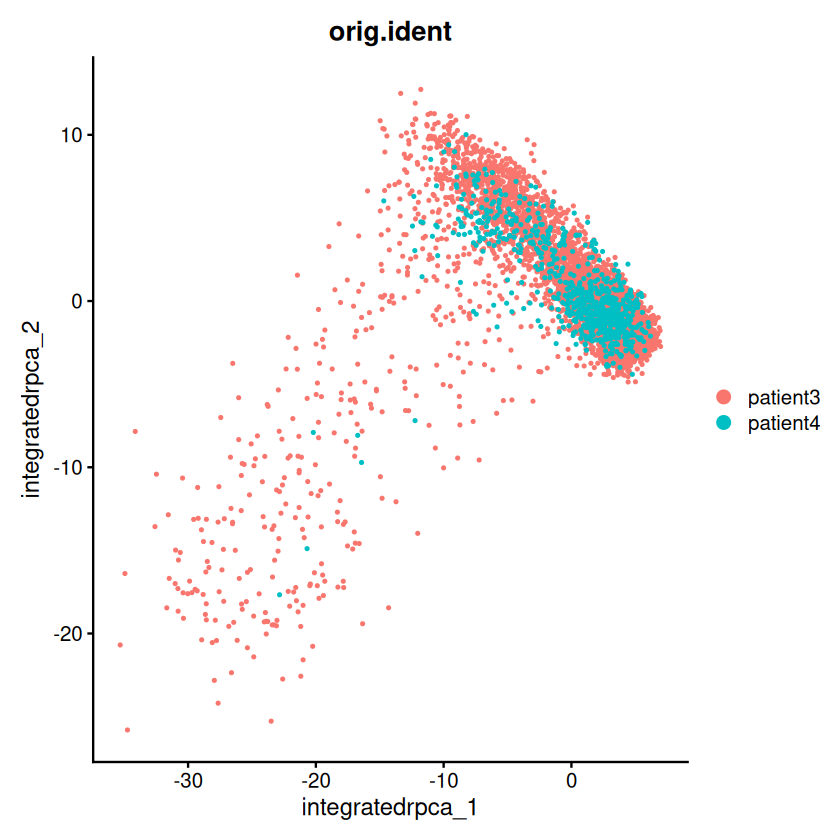

In [50]:
DimPlot(merged_seurat, reduction = "integrated.rpca", group.by = "orig.ident")

## 6. scRepertoire on patients 3 and 4 - integrated. data

In [51]:
#' #Getting a sample of a Seurat object
#' scRep_example <- get(data("scRep_example"))
#' 
#' #Using combineExpresion()
#' scRep_example <- combineExpression(combined, scRep_example)

In [52]:
contig_list_1
contig_list_2

,barcode,chain,reads,v_gene,d_gene,j_gene,c_gene,cdr3_nt,cdr3
,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
67,498638,TRA,1,TRAV29/DV5*01,,TRAJ18*01,,TGTGCAGCAAGCCCAGAGGGCTCAACCCTGGGGGG,VQQAQRAQPWG
264,1856846,TRA,1,TRAV12-3*01,,TRAJ3*01,,TTTGCAATTAGCGACCCCTCCAGCAGTGCTTCCAGGATAATCTTT,FAISDPSSSASRIIF
324,2231415,TRA,1,TRAV16*01,,TRAJ42*01,,TGTGCTCTAACGGGGACGGGGTATGGAGGAAGCCAAGGGAATCT,CALTGTGYGGSQGNL
432,3011071,TRA,1,TRAV4*01,,TRAJ33*01,TRBC1,TGCCTCGTGGGTGATAGCAACTATCAGTTAATCTGG,CLVGDSNYQLIW
458,3219416,TRA,1,TRAV21*01,,TRAJ17*01,,CGTGCTGGTCTCATGATCAAAGCTGCAGGCAGCAAGCTAACTATT,RAGLMIKAAGSKLTI
506,3483965,TRA,1,TRAV29/DV5*01,,TRAJ37*02,,TGTGCAACTTTAAGCAACACAGGCAAACGAATCTTT,CATLSNTGKRIF
684,4651849,TRA,1,TRAV1-2*01,,TRAJ16*01,,TGTGCTGTGAGAGATCGGTTTGCAGATGGCCAGAAGCGGCTCTTT,CAVRDRFADGQKRLF
752,5168750,TRA,1,TRAV38-2/DV8*01,,TRAJ43*01,,TGTGCTTATCGGAATAACAATGACATGCGCTTT,CAYRNNNDMRF
761,5192988,TRA,1,TRAV21*01,,TRAJ42*01,TRAC,TGTGCTGTGGCTATGGAGGAAGCCAAGGAAATCTCATCTTT,CAVAMEEAKEISS


,barcode,chain,reads,v_gene,d_gene,j_gene,c_gene,cdr3_nt,cdr3
,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
190,11226389,TRA,1,TRAV21*01,,TRAJ18*01,IGHA1,TGTGCTGTTGATAGCGGCAGAGGCTCAACCCTGGGGGTA,CAVDSGRGSTLGV
386,22733773,TRA,1,TRAV38-2/DV8*01,,TRAJ30*01,,TGTGCTAGCAGATGACAAGATCATCTTT,CASR*QDHL
835,44116358,TRB,1,TRBV28*01,TRBD2*01,TRBJ2-7*01,TRBC2,TGTGCCAGCAGTTTATGGCGGCGGGGCGAGCAGCACTTC,CASSLWRRGEQHF
64,3784046,TRA,2,TRAV21*01,,TRAJ18*01,,TGTGCTGTTGATAGCGGCAGAGGCTCAACCCTGGGGAGGCAAG,CAVDSGRGSTLGRQ
161,9653855,TRA,2,TRAV1-1*01,,TRAJ31*01,,TGCGCTGTGAACAACAATGCCAGACTCAAGA,CAVNNNARLK
327,19483736,TRA,2,TRAV21*01,,TRAJ18*01,,TGTGCTGTTGATAGCGGCAGAGGCTCAACCCGGGGGAGGC,CAVDSGRGSTRGR
434,25384037,TRA,2,TRAV5*01,,TRAJ21*01,TRAC,TGTGCAGAGAGTCCCTCTTGGGACAACTTCAACAAATTCTACTTT,CAESPSWDNFNKFYF
594,33095881,TRA,2,TRAV38-1*01,,TRAJ37*02,,TGTGCTTTCATGAAGTTAACCGTCACTCCTATCGTCTCTAGCAACACAGGCAAACTA,CAFMKLTVTPIVSSNTGKL
615,33909949,TRA,2,TRAV13-1*01,,TRAJ36*01,TRAC,TGTGCAGCAAATGGGGCAAACAGCCTCTTCTTT,CAANGANSLFF


In [53]:
#combined.TCR_all <- combineTCR(
#  list(contig_list_1, contig_list_2),
#  samples = c("P3_S1", "P4_S1"), 
#  removeNA = TRUE,
#  removeMulti = FALSE,
#  filterMulti = FALSE
#)

In [54]:
# flatten and same as above
combined.TCR_all <- combineTCR(
  c(contig_list_1, contig_list_2),
  samples = c("P3_S1", "P4_S1"),
  removeNA = TRUE,
  removeMulti = FALSE,
  filterMulti = FALSE
)

In [55]:
class(combined.TCR_all)
attributes(combined.TCR_all)
#str(combined.TCR_all)

[1] "list"

$names
[1] "P3_S1" "P4_S1"

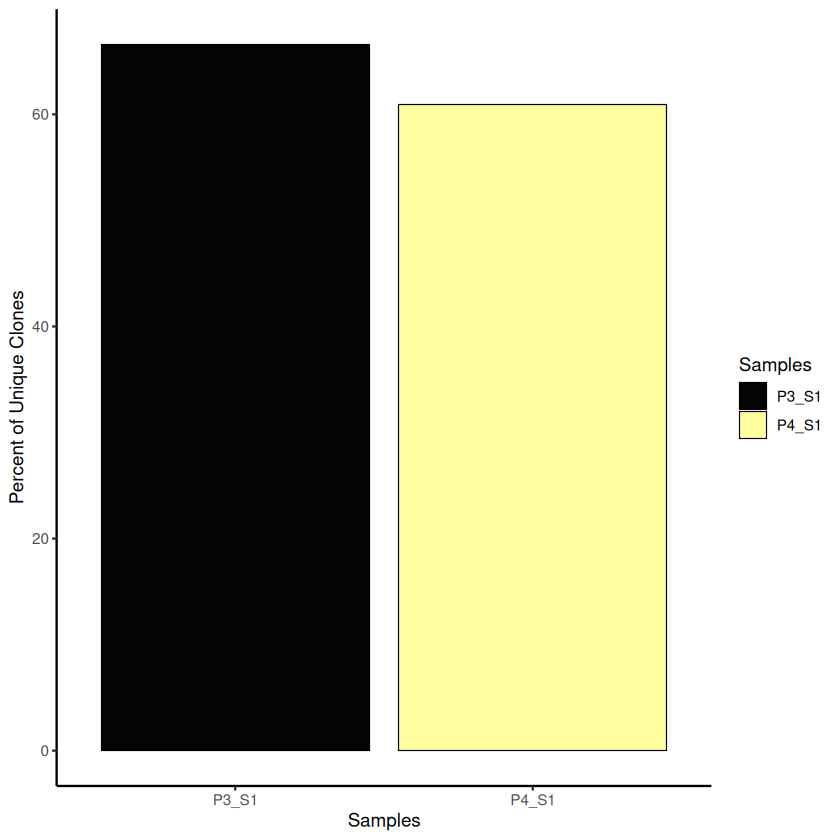

In [56]:
# total or relative numbers of unique clones.
clonalQuant(combined.TCR_all, 
            cloneCall="strict", 
            chain = "both", 
            scale = TRUE)

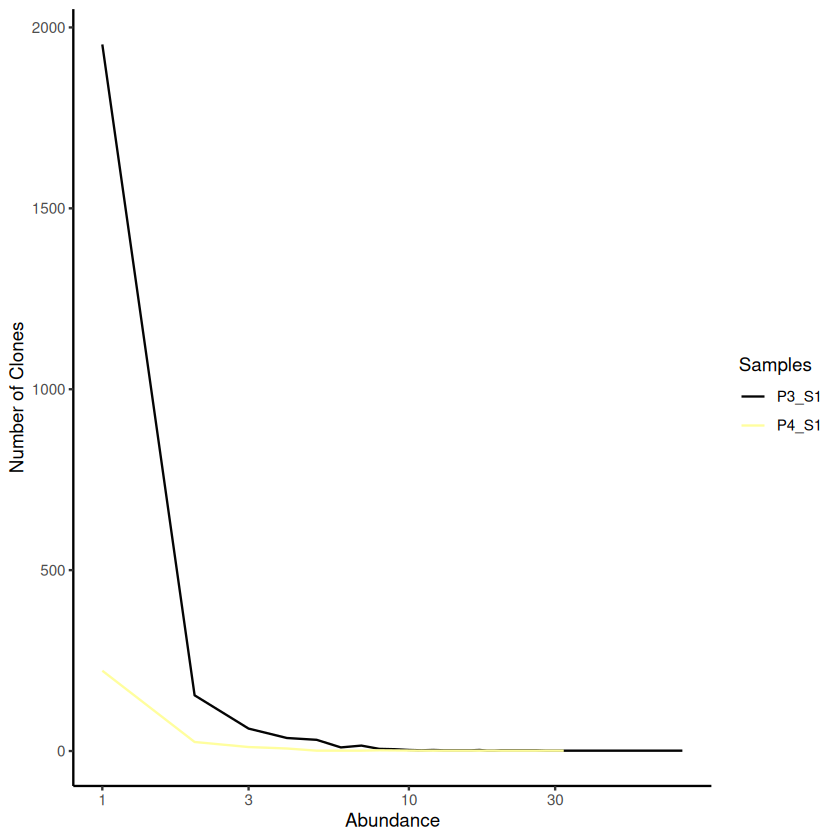

In [57]:
# a total number of clones by the number of instances within the sample or run
clonalAbundance(combined.TCR_all, 
                cloneCall = "gene", 
                scale = FALSE)

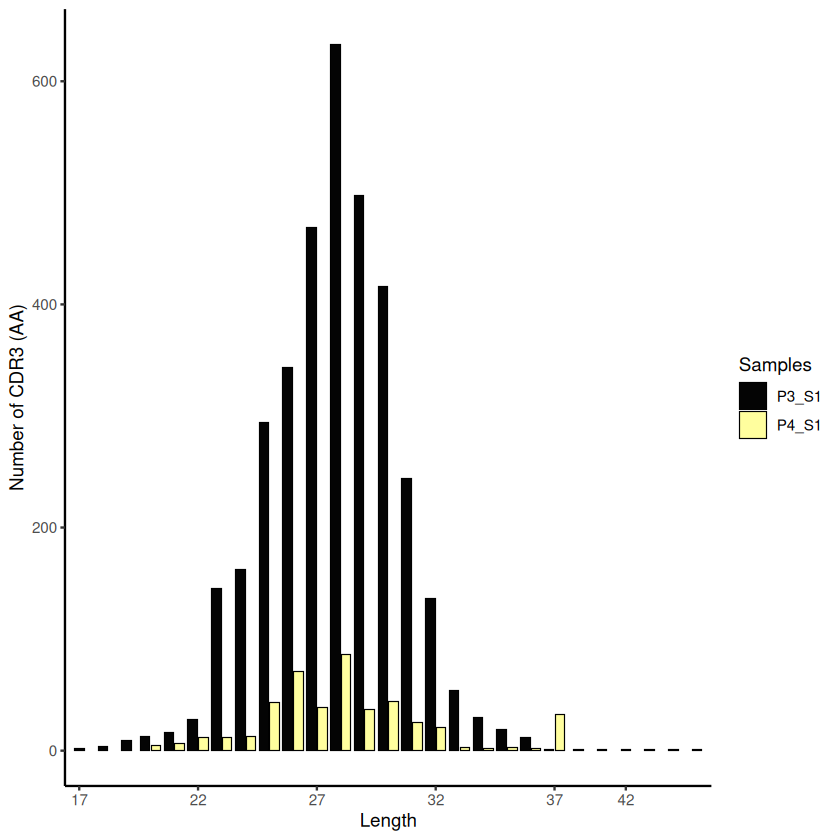

In [58]:
clonalLength(combined.TCR_all, 
             cloneCall="aa", 
             chain = "both") 

## combineExpression() on patient 3

In [59]:
head(combined.TCR_p3[[1]]$barcode)

[1] "P3_S1_10006345" "P3_S1_10007655" "P3_S1_10024172" "P3_S1_10069653"
[5] "P3_S1_10075139" "P3_S1_10088479"

In [60]:
rownames(patient3_transform@meta.data)

[1] "4100"     "4977"     "11356"    "21277"    "30102"    "41586"   
   [7] "41975"    "66729"    "71338"    "76819"    "79100"    "84344"   
  [13] "92469"    "107794"   "110048"   "115875"   "128432"   "130887"  
  [19] "148595"   "150698"   "200482"   "245359"   "251956"   "252164"  
  [25] "257516"   "259126"   "298564"   "314412"   "317874"   "318796"  
  [31] "321730"   "328754"   "334809"   "336037"   "368722"   "387338"  
  [37] "402675"   "403609"   "416679"   "421198"   "423827"   "437804"  
  [43] "449991"   "470372"   "472973"   "498638"   "502921"   "534829"  
  [49] "536223"   "544189"   "568013"   "591437"   "596830"   "609045"  
  [55] "613271"   "639731"   "670535"   "683186"   "686504"   "687736"  
  [61] "689518"   "692586"   "729326"   "731827"   "735481"   "737760"  
  [67] "750830"   "767476"   "775951"   "787942"   "790604"   "791864"  
  [73] "804796"   "813789"   "819724"   "829582"   "840439"   "846837"  
  [79] "859052"   "872360"   "884624"   "891284"   "905069"   "906154"  
  [85] "906628"   "910085"   "947895"   "952613"   "984732"   "998594"  
  [91] "1017136"  "1023353"  "1047768"  "1070356"  "1096665"  "1105156" 
  [97] "1109301"  "1160633"  "1175228"  "1177781"  "1179936"  "1224303" 
 [103] "1225789"  "1227744"  "1230634"  "1240761"  "1245100"  "1263397" 
 [109] "1273364"  "1273841"  "1275003"  "1284853"  "1287376"  "1291855" 
 [115] "1300074"  "1311340"  "1332497"  "1332850"  "1334413"  "1335654" 
 [121] "1342106"  "1343778"  "1346620"  "1347386"  "1355361"  "1367429" 
 [127] "1368719"  "1369737"  "1371124"  "1409611"  "1419055"  "1424048" 
 [133] "1438988"  "1449571"  "1470319"  "1473252"  "1492672"  "1498363" 
 [139] "1505098"  "1506826"  "1512948"  "1520029"  "1546262"  "1551080" 
 [145] "1552536"  "1572242"  "1605109"  "1605386"  "1618589"  "1619754" 
 [151] "1625452"  "1629412"  "1640387"  "1646079"  "1651804"  "1679120" 
 [157] "1680631"  "1683667"  "1683884"  "1698696"  "1720257"  "1728954" 
 [163] "1732465"  "1765343"  "1768323"  "1771443"  "1785247"  "1788901" 
 [169] "1793354"  "1840959"  "1841536"  "1843121"  "1856846"  "1857636" 
 [175] "1861919"  "1862897"  "1863220"  "1863355"  "1866061"  "1872224" 
 [181] "1874857"  "1877289"  "1889596"  "1922624"  "1926232"  "1942216" 
 [187] "1959325"  "1966357"  "1969196"  "1987993"  "1993890"  "2008670" 
 [193] "2013598"  "2033982"  "2037520"  "2052871"  "2067210"  "2080638" 
 [199] "2086294"  "2112786"  "2123858"  "2140566"  "2162754"  "2177033" 
 [205] "2177635"  "2185640"  "2190643"  "2195500"  "2212234"  "2218319" 
 [211] "2223350"  "2231415"  "2236681"  "2262562"  "2267322"  "2271172" 
 [217] "2280483"  "2331868"  "2375925"  "2389419"  "2395696"  "2400856" 
 [223] "2405488"  "2405772"  "2427758"  "2432528"  "2442313"  "2468528" 
 [229] "2482383"  "2491652"  "2496049"  "2522002"  "2533614"  "2544643" 
 [235] "2565767"  "2574586"  "2578996"  "2602974"  "2604464"  "2605277" 
 [241] "2607016"  "2610275"  "2648214"  "2657628"  "2659088"  "2664362" 
 [247] "2681702"  "2682672"  "2686157"  "2687683"  "2712164"  "2777835" 
 [253] "2797399"  "2812901"  "2822988"  "2826729"  "2828504"  "2837794" 
 [259] "2846721"  "2858691"  "2858945"  "2861889"  "2868967"  "2871637" 
 [265] "2874016"  "2921700"  "2928334"  "2932374"  "2942053"  "2980976" 
 [271] "2986824"  "3000610"  "3005209"  "3011071"  "3031905"  "3041079" 
 [277] "3058775"  "3075977"  "3076733"  "3083077"  "3091239"  "3104894" 
 [283] "3133585"  "3145837"  "3147289"  "3153440"  "3155942"  "3213719" 
 [289] "3216516"  "3219416"  "3224883"  "3232346"  "3234848"  "3254198" 
 [295] "3261973"  "3271817"  "3273967"  "3277360"  "3280442"  "3290764" 
 [301] "3317825"  "3336601"  "3363451"  "3365614"  "3368389"  "3381803" 
 [307] "3385870"  "3389140"  "3405835"  "3422000"  "3436893"  "3445487" 
 [313] "3449354"  "3450623"  "3457554"  "3461342"  "3468840"  "3472621" 
 [319] "3482537"  "3483965"  "3497718"  "3511070"  "3513686"  "3519201" 
 [325] "3530032"  "3544347"  "3553817"  "3556121"  "3567704" 

In [61]:
# Matching the barcodes = removing the 'PS'
combined.TCR_p3 <- lapply(combined.TCR_p3, function(x) {
  x$barcode <- gsub("P3_S1_", "", x$barcode)
  return(x)
})

In [62]:
head(colnames(patient3_transform@meta.data))
colnames(combined.TCR_p3[[1]])
head(combined.TCR_p3[[1]]$barcode, 10)
barcodes_tcr <- unlist(lapply(combined.TCR_p3, function(x) x$barcode))
head(barcodes_tcr, 10)
barcodes_seurat <- colnames(patient3_transform)
head(barcodes_seurat, 10)

[1] "orig.ident"   "nCount_RNA"   "nFeature_RNA" "percent.mt"   "nCount_SCT"  
[6] "nFeature_SCT"

[1] "barcode"  "sample"   "TCR1"     "cdr3_aa1" "cdr3_nt1" "TCR2"    
 [7] "cdr3_aa2" "cdr3_nt2" "CTgene"   "CTnt"     "CTaa"     "CTstrict"

[1] "10006345" "10007655" "10024172" "10069653" "10075139" "10088479"
 [7] "10094917" "10115275" "10161117" "10181728"

P3_S11     P3_S12     P3_S13     P3_S14     P3_S15     P3_S16     P3_S17 
"10006345" "10007655" "10024172" "10069653" "10075139" "10088479" "10094917" 
    P3_S18     P3_S19    P3_S110 
"10115275" "10161117" "10181728"

[1] "4100"  "4977"  "11356" "21277" "30102" "41586" "41975" "66729" "71338"
[10] "76819"

In [63]:
#intersect(combined.TCR_p3[[i]]$barcode, rownames(patient3_transform@meta.data))

#length(intersect(combined.TCR_p3[[i]]$barcode, rownames(patient3_transform@meta.data)))

In [64]:
#patient3_transform$orig.ident <- as.character(patient3_transform$orig.ident)

In [65]:
sce_patient3 <- combineExpression(
  combined.TCR_p3,
  patient3_transform,
  cloneCall = "CTgene",
  group.by = "sample",
  proportion = TRUE,
  cloneSize = c(Single = 1, Small = 5, Medium = 20, Large = 100, Hyperexpanded = 500)
)

In [66]:
sce_patient3
colnames(sce_patient3@meta.data)

An object of class Seurat 
44925 features across 5739 samples within 2 assays 
Active assay: SCT (21234 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 1 other assay present: RNA

[1] "orig.ident"       "nCount_RNA"       "nFeature_RNA"     "percent.mt"      
 [5] "nCount_SCT"       "nFeature_SCT"     "CTgene"           "CTnt"            
 [9] "CTaa"             "CTstrict"         "clonalProportion" "clonalFrequency" 
[13] "cloneSize"

## combineExpression() on patient 4

In [67]:
head(combined.TCR_p4[[1]]$barcode)

[1] "P4_S1_1002101"  "P4_S1_10279593" "P4_S1_10311423" "P4_S1_10627379"
[5] "P4_S1_10742731" "P4_S1_10800031"

In [68]:
# Matching the barcodes = removing the 'PS' now for patient 4
combined.TCR_p4 <- lapply(combined.TCR_p4, function(x) {
  x$barcode <- gsub("P4_S1_", "", x$barcode)
  return(x)
})

In [69]:
sce_patient4 <- combineExpression(
  combined.TCR_p4,
  patient4_transform,
  cloneCall = "CTgene",
  group.by = "sample",
  proportion = TRUE,
  cloneSize = c(Single = 1, Small = 5, Medium = 20, Large = 100, Hyperexpanded = 500)
)

In [70]:
sce_patient4
colnames(sce_patient4@meta.data)

An object of class Seurat 
30351 features across 750 samples within 2 assays 
Active assay: SCT (13866 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 1 other assay present: RNA

[1] "orig.ident"       "nCount_RNA"       "nFeature_RNA"     "percent.mt"      
 [5] "nCount_SCT"       "nFeature_SCT"     "CTgene"           "CTnt"            
 [9] "CTaa"             "CTstrict"         "clonalProportion" "clonalFrequency" 
[13] "cloneSize"

## combineExpression() on integrated_seurat object and combined.TCR_all screp object

In [71]:
combined.TCR_all

,barcode,sample,TCR1,cdr3_aa1,cdr3_nt1,TCR2,cdr3_aa2,cdr3_nt2,CTgene,CTnt,CTaa,CTstrict
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,P3_S1_10006345,P3_S1,TRAV35*01.TRAJ18*01.TRAC,CAGPDRGSTLGRLYF,TGTGCTGGACCCGACAGAGGCTCAACCCTGGGGAGGCTATACTTT,TRBV20-1*01.TRBD2*01.TRBJ2-1*01.TRBC2,CSARGLGGSYNEQFF,TGCAGTGCTAGAGGATTGGGGGGGTCCTACAATGAGCAGTTCTTC,TRAV35*01.TRAJ18*01.TRAC_TRBV20-1*01.TRBD2*01.TRBJ2-1*01.TRBC2,TGTGCTGGACCCGACAGAGGCTCAACCCTGGGGAGGCTATACTTT_TGCAGTGCTAGAGGATTGGGGGGGTCCTACAATGAGCAGTTCTTC,CAGPDRGSTLGRLYF_CSARGLGGSYNEQFF,TRAV35*01.TRAJ18*01.TRAC;TGTGCTGGACCCGACAGAGGCTCAACCCTGGGGAGGCTATACTTT_TRBV20-1*01.TRBD2*01.TRBJ2-1*01.TRBC2;TGCAGTGCTAGAGGATTGGGGGGGTCCTACAATGAGCAGTTCTTC
3,P3_S1_10007655,P3_S1,TRAV17*01.TRAJ4*01.TRAC,CATDLFSGGYNKLIF,TGTGCTACGGATCTCTTTTCTGGTGGCTACAATAAGCTGATTTTT,TRBV6-6*01.TRBD2*01.TRBJ2-7*01.TRBC2,CASSQAGEQYF,TGTGCCAGCAGCCAGGCGGGCGAGCAGTACTTC,TRAV17*01.TRAJ4*01.TRAC_TRBV6-6*01.TRBD2*01.TRBJ2-7*01.TRBC2,TGTGCTACGGATCTCTTTTCTGGTGGCTACAATAAGCTGATTTTT_TGTGCCAGCAGCCAGGCGGGCGAGCAGTACTTC,CATDLFSGGYNKLIF_CASSQAGEQYF,TRAV17*01.TRAJ4*01.TRAC;TGTGCTACGGATCTCTTTTCTGGTGGCTACAATAAGCTGATTTTT_TRBV6-6*01.TRBD2*01.TRBJ2-7*01.TRBC2;TGTGCCAGCAGCCAGGCGGGCGAGCAGTACTTC
5,P3_S1_10024172,P3_S1,TRAV12-1*01.TRAJ42*01.TRAC,CVVNLAYYGGSQGNLIF,TGTGTGGTGAACCTTGCTTATTATGGAGGAAGCCAAGGAAATCTCATCTTT,TRBV9*01.NA.TRBJ1-5*01.TRBC1,CASSPGPSQPQHF,TGTGCCAGCAGCCCAGGACCGAGTCAGCCCCAGCATTTT,TRAV12-1*01.TRAJ42*01.TRAC_TRBV9*01.NA.TRBJ1-5*01.TRBC1,TGTGTGGTGAACCTTGCTTATTATGGAGGAAGCCAAGGAAATCTCATCTTT_TGTGCCAGCAGCCCAGGACCGAGTCAGCCCCAGCATTTT,CVVNLAYYGGSQGNLIF_CASSPGPSQPQHF,TRAV12-1*01.TRAJ42*01.TRAC;TGTGTGGTGAACCTTGCTTATTATGGAGGAAGCCAAGGAAATCTCATCTTT_TRBV9*01.NA.TRBJ1-5*01.TRBC1;TGTGCCAGCAGCCCAGGACCGAGTCAGCCCCAGCATTTT
7,P3_S1_10069653,P3_S1,TRAV3*01.TRAJ34*01.NA;TRGV2*01.TRGJP1*01.NA,CAVRGSIGTDKLIF;CATWDGFGWFKIF,TGTGCTGTGAGAGGTTCAATAGGAACCGACAAGCTCATCTTT;TGTGCCACCTGGGACGGGTTCGGTTGGTTCAAGATATTT,TRDV3*01.TRDD3*01.TRDJ1*01.TRDC,CAFNRNWGIHSDKLIF,TGTGCCTTTAATCGAAACTGGGGGATACATTCCGATAAACTCATCTTT,TRAV3*01.TRAJ34*01.NA;TRGV2*01.TRGJP1*01.NA_TRDV3*01.TRDD3*01.TRDJ1*01.TRDC,TGTGCTGTGAGAGGTTCAATAGGAACCGACAAGCTCATCTTT;TGTGCCACCTGGGACGGGTTCGGTTGGTTCAAGATATTT_TGTGCCTTTAATCGAAACTGGGGGATACATTCCGATAAACTCATCTTT,CAVRGSIGTDKLIF;CATWDGFGWFKIF_CAFNRNWGIHSDKLIF,TRAV3*01.TRAJ34*01.NA;TRGV2*01.TRGJP1*01.NA;TGTGCTGTGAGAGGTTCAATAGGAACCGACAAGCTCATCTTT;TGTGCCACCTGGGACGGGTTCGGTTGGTTCAAGATATTT_TRDV3*01.TRDD3*01.TRDJ1*01.TRDC;TGTGCCTTTAATCGAAACTGGGGGATACATTCCGATAAACTCATCTTT
10,P3_S1_10075139,P3_S1,TRAV19*01.TRAJ6*01.TRAC,CALSGRSGGSYIPTF,TGTGCTCTGAGTGGTAGATCAGGAGGAAGCTACATACCTACATTT,TRBV7-9*03.NA.TRBJ1-1*01.TRBC1,CASSFADSTTEAFF,TGTGCCAGCAGCTTTGCCGATTCTACCACTGAAGCTTTCTTT,TRAV19*01.TRAJ6*01.TRAC_TRBV7-9*03.NA.TRBJ1-1*01.TRBC1,TGTGCTCTGAGTGGTAGATCAGGAGGAAGCTACATACCTACATTT_TGTGCCAGCAGCTTTGCCGATTCTACCACTGAAGCTTTCTTT,CALSGRSGGSYIPTF_CASSFADSTTEAFF,TRAV19*01.TRAJ6*01.TRAC;TGTGCTCTGAGTGGTAGATCAGGAGGAAGCTACATACCTACATTT_TRBV7-9*03.NA.TRBJ1-1*01.TRBC1;TGTGCCAGCAGCTTTGCCGATTCTACCACTGAAGCTTTCTTT
12,P3_S1_10088479,P3_S1,TRAV13-1*01.TRAJ54*01.TRAC,CAASMVGAQKLVF,TGTGCAGCAAGTATGGTTGGAGCCCAGAAGCTGGTATTT,TRBV28*01.TRBD1*01.TRBJ2-7*01.TRBC2,CASSLSLGASYEQYF,TGTGCCAGCAGTTTATCTTTGGGGGCCTCCTACGAGCAGTACTTC,TRAV13-1*01.TRAJ54*01.TRAC_TRBV28*01.TRBD1*01.TRBJ2-7*01.TRBC2,TGTGCAGCAAGTATGGTTGGAGCCCAGAAGCTGGTATTT_TGTGCCAGCAGTTTATCTTTGGGGGCCTCCTACGAGCAGTACTTC,CAASMVGAQKLVF_CASSLSLGASYEQYF,TRAV13-1*01.TRAJ54*01.TRAC;TGTGCAGCAAGTATGGTTGGAGCCCAGAAGCTGGTATTT_TRBV28*01.TRBD1*01.TRBJ2-7*01.TRBC2;TGTGCCAGCAGTTTATCTTTGGGGGCCTCCTACGAGCAGTACTTC
14,P3_S1_10094917,P3_S1,TRAV1-2*01.TRAJ16*01.NA,CAARDGQKLLF,TGTGCTGCCCGGGATGGCCAGAAGCTGCTCTTT,TRBV19*01.NA.TRBJ2-3*01.TRBC2,CASSIEMAAGFRTDTQYF,TGTGCCAGTAGTATAGAGATGGCCGCCGGTTTTCGGACAGATACGCAGTATTTT,TRAV1-2*01.TRAJ16*01.NA_TRBV19*01.NA.TRBJ2-3*01.TRBC2,TGTGCTGCCCGGGATGGCCAGAAGCTGCTCTTT_TGTGCCAGTAGTATAGAGATGGCCGCCGGTTTTCGGACAGATACGCAGTATTTT,CAARDGQKLLF_CASSIEMAAGFRTDTQYF,TRAV1-2*01.TRAJ16*01.NA;TGTGCTGCCCGGGATGGCCAGAAGCTGCTCTTT_TRBV19*01.NA.TRBJ2-3*01.TRBC2;TGTGCC

In [72]:
head(combined.TCR_all[[1]]$barcode)
head(combined.TCR_all[[2]]$barcode)

[1] "P3_S1_10006345" "P3_S1_10007655" "P3_S1_10024172" "P3_S1_10069653"
[5] "P3_S1_10075139" "P3_S1_10088479"

[1] "P4_S1_1002101"  "P4_S1_10279593" "P4_S1_10311423" "P4_S1_10627379"
[5] "P4_S1_10742731" "P4_S1_10800031"

In [73]:
merged_seurat
colnames(merged_seurat@meta.data)

An object of class Seurat 
45180 features across 6489 samples within 2 assays 
Active assay: RNA (23874 features, 2000 variable features)
 5 layers present: counts.patient3, counts.patient4, data.patient3, data.patient4, scale.data
 1 other assay present: SCT
 3 dimensional reductions calculated: pca, pca.rna, integrated.rpca

[1] "orig.ident"   "nCount_RNA"   "nFeature_RNA" "percent.mt"   "nCount_SCT"  
[6] "nFeature_SCT"

In [74]:
combined.TCR_all <- lapply(combined.TCR_all, function(x) {
  x$barcode <- gsub("^P[0-9]+_S[0-9]+_", "", x$barcode)
  return(x)
})

In [75]:
sce_all_patients_new <- combineExpression(
  combined.TCR_all,
  merged_seurat, 
  cloneCall = "CTgene", 
  group.by = "sample",
  proportion = TRUE,
  cloneSize = c(Single = 1, Small = 5, Medium = 20, Large = 100, Hyperexpanded = 500)
)

In [76]:
sce_all_patients_new

An object of class Seurat 
45180 features across 6489 samples within 2 assays 
Active assay: RNA (23874 features, 2000 variable features)
 5 layers present: counts.patient3, counts.patient4, data.patient3, data.patient4, scale.data
 1 other assay present: SCT
 3 dimensional reductions calculated: pca, pca.rna, integrated.rpca

In [77]:
colnames(sce_all_patients_new@meta.data)

[1] "orig.ident"       "nCount_RNA"       "nFeature_RNA"     "percent.mt"      
 [5] "nCount_SCT"       "nFeature_SCT"     "CTgene"           "CTnt"            
 [9] "CTaa"             "CTstrict"         "clonalProportion" "clonalFrequency" 
[13] "cloneSize"

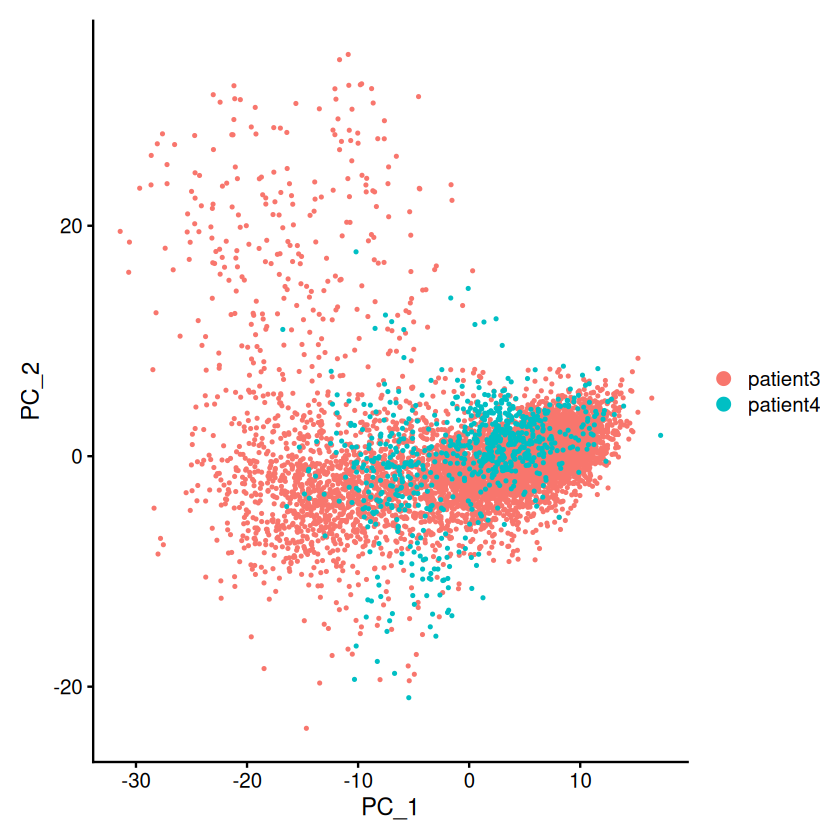

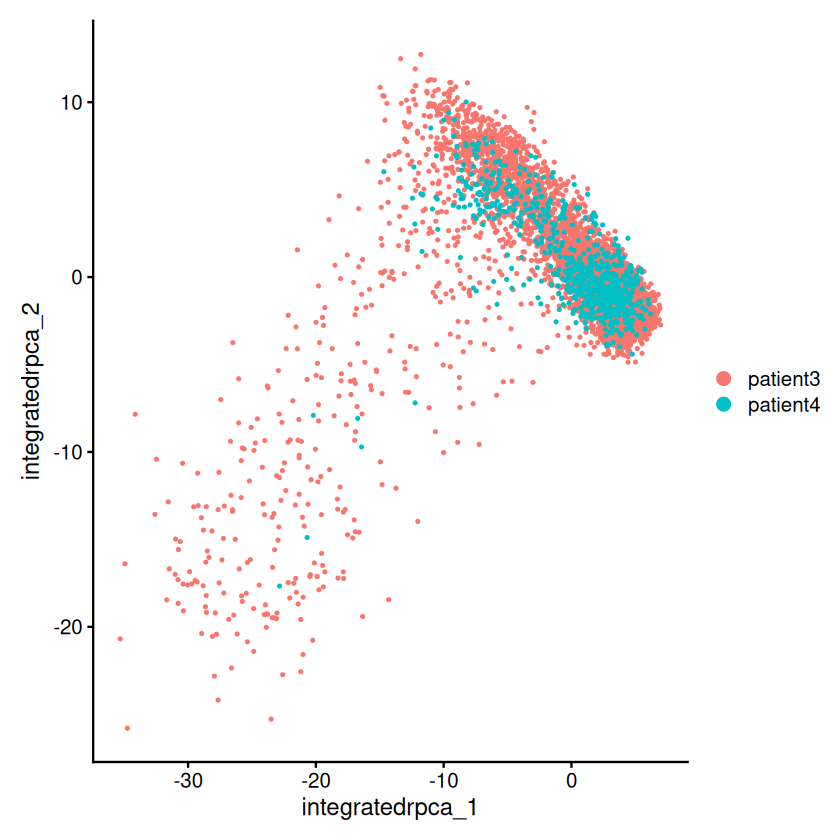

In [78]:
DimPlot(sce_all_patients_new, reduction = "pca") 
DimPlot(sce_all_patients_new, reduction = "integrated.rpca")

In [79]:
sce_all_patients_new <- RunPCA(sce_all_patients_new)
sce_all_patients_new <- RunUMAP(sce_all_patients_new, dims = 1:30)
sce_all_patients_new <- FindNeighbors(sce_all_patients_new, dims = 1:30)
sce_all_patients_new <- FindClusters(sce_all_patients_new, resolution = 0.5) # for even lower cluster, I found setting it 0.3 helps

PC_ 1 
Positive:  IL7R, KLF2, FTH1, SELL, SATB1, ANXA1, FOS, S1PR1, SESN3, LNCRNA-IUR 
	   MT-CO3, RPS2, YBX3, ZBTB16, SNED1, RPS18, GPCPD1, IRS2, GPR183, KRT1 
	   RNF130, ACTN1, BACH2, ARL4C, MBP, KCNA3, ABLIM1, ZHX2, SCML1, MT-CO1 
Negative:  TYMS, DUSP4, MKI67, HLA-DRB1, RRM2, TOP2A, CXCL13, HLA-DRA, NCAPG, CENPU 
	   MYO7A, RBPJ, ASPM, TPX2, KIF11, CCNA2, ITGAE, GZMB, STMN1, CDK1 
	   CTLA4, HLA-DRB6, APOBEC3C, UBE2C, CD74, HSPA1A, HMGB2, CCL5, PMAIP1, NKG7 
PC_ 2 
Positive:  DUSP4, CCL5, MYO7A, TNFRSF9, CBLB, ITGAE, LYST, NKG7, CXCL13, KRT86 
	   AKAP5, LAYN, RGS1, HSPA1A, ETV1, PRDM1, VCAM1, RBPJ, CXCR6, GZMB 
	   CTLA4, HAVCR2, ADGRG1, TOX, HLA-DRB1, IKZF3, PRF1, RDH10, GOLIM4, DTHD1 
Negative:  RRM2, MKI67, TYMS, TOP2A, NCAPG, TUBB, UBE2C, ZWINT, CDCA5, CDK1 
	   CENPU, IL7R, BIRC5, KIF18B, KIF11, STMN1, PCLAF, ASPM, SELL, ASF1B 
	   FTH1, KLF2, CDKN3, UHRF1, CCNA2, KIFC1, RAD51, PRR11, VIM, MT-CO3 
PC_ 3 
Positive:  NR4A1, FOSB, HSPA1A, NR4A2, HSPA8, DNAJB1, EGR1, KLF6, ID2, 

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 6489
Number of edges: 256122

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8419
Number of communities: 11
Elapsed time: 0 seconds


In [80]:
colnames(sce_all_patients_new@meta.data)

[1] "orig.ident"       "nCount_RNA"       "nFeature_RNA"     "percent.mt"      
 [5] "nCount_SCT"       "nFeature_SCT"     "CTgene"           "CTnt"            
 [9] "CTaa"             "CTstrict"         "clonalProportion" "clonalFrequency" 
[13] "cloneSize"        "RNA_snn_res.0.5"  "seurat_clusters"

In [81]:
sce_all_patients_new@meta.data$seurat_clusters

[1] 5  1  0  2  5  0  2  1  2  1  0  3  3  0  1  1  4  0  3  3  1  2  4  1 
  [25] 2  1  1  1  1  3  0  0  1  3  3  0  7  2  0  0  0  0  1  1  3  0  3  0 
  [49] 0  2  4  5  1  0  1  0  4  2  0  2  1  3  1  1  0  0  0  5  0  1  0  1 
  [73] 2  0  2  2  3  1  8  2  1  0  1  2  3  1  1  2  0  4  5  2  0  3  3  1 
  [97] 3  1  1  0  2  0  2  0  1  0  0  0  2  1  4  1  1  0  4  1  3  2  5  3 
 [121] 2  0  5  0  1  3  9  3  2  5  0  3  2  3  3  0  2  3  2  0  2  0  3  0 
 [145] 0  3  3  0  0  0  3  0  1  1  1  5  1  1  0  0  0  0  0  5  0  1  3  2 
 [169] 2  7  0  2  0  2  5  0  2  2  0  1  1  1  0  0  4  1  2  0  0  2  2  0 
 [193] 2  1  0  1  3  0  2  2  3  0  8  0  2  2  1  2  1  2  4  0  3  0  1  1 
 [217] 0  1  1  1  3  1  2  4  0  5  2  1  3  0  4  1  2  0  5  1  1  3  1  2 
 [241] 0  2  4  2  2  1  1  3  0  5  3  1  3  3  2  2  1  1  3  0  2  0  2  1 
 [265] 2  1  2  3  5  1  0  0  2  7  4  0  7  2  2  3  3  0  3  2  4  1  3  3 
 [289] 3  0  0  1  0  1  0  5  2  0  7  1  2  0  2  5  2  0  2  0  0  3  0  2 
 [313] 2  0  1  2  0  2  2  1  2  5  1  0  2  3  1  5  8  1  1  3  5  0  0  1 
 [337] 2  3  1  0  3  0  0  2  0  0  0  2  5  0  0  7  0  3  0  3  1  2  2  0 
 [361] 0  0  0  3  3  0  0  0  4  1  1  0  0  3  0  1  0  2  0  2  0  0  5  1 
 [385] 2  0  0  0  7  0  5  0  0  2  0  3  5  1  1  0  4  0  2  1  3  1  1  2 
 [409] 1  1  0  1  0  1  1  1  0  0  1  2  3  9  2  1  2  0  8  2  0  1  4  7 
 [433] 3  5  0  0  0  2  4  0  2  3  2  0  5  3  5  3  0  0  5  0  0  8  0  0 
 [457] 0  7  0  0  5  1  1  7  0  0  0  4  1  1  0  1  0  0  2  0  3  1  3  0 
 [481] 2  1  0  3  5  0  2  2  3  0  2  2  0  1  0  1  3  3  0  1  1  1  0  5 
 [505] 1  3  0  1  0  1  1  0  3  0  0  4  2  2  2  2  2  0  0  0  1  2  0  1 
 [529] 1  0  5  1  5  7  0  0  0  3  1  4  0  1  4  0  0  0  0  1  3  0  0  1 
 [553] 2  2  0  2  0  1  2  3  5  0  8  0  0  1  0  0  1  1  1  3  8  1  1  2 
 [577] 3  3  0  3  0  2  0  1  3  1  7  0  3  0  0  1  1  0  3  0  0  5  0  0 
 [601] 2  1  1  1  2  3  3  9  0  1  1  5  3  0  0  0  1  4  0  0  1  0  1  0 
 [625] 3  0  0  0  5  2  3  3  0  0  3  1  1  1  1  2  1  2  1  5  2  0  0  0 
 [649] 2  2  0  1  0  4  1  1  0  2  2  1  0  2  2  7  0  1  0  0  1  0  3  1 
 [673] 8  1  0  3  2  5  1  0  4  1  2  0  0  0  0  3  3  3  1  3  0  2  0  1 
 [697] 0  0  5  0  2  0  4  3  3  5  0  1  3  0  2  2  3  3  0  1  2  2  1  1 
 [721] 2  1  0  0  4  2  3  1  1  1  1  3  7  3  4  0  5  2  0  2  2  0  1  0 
 [745] 2  1  2  5  4  4  0  0  0  5  3  1  0  2  0  1  1  0  8  0  0  3  1  0 
 [769] 1  3  2  2  0  3  0  1  1  0  2  0  0  9  2  0  0  9  2  0  2  3  3  0 
 [793] 1  4  3  1  1  1  0  0  7  4  0  0  0  3  0  0  3  1  2  1  0  0  2  0 
 [817] 1  2  1  5  3  0  1  3  3  1  2  2  3  2  1  3  0  0  1  3  3  1  2  2 
 [841] 3  2  2  1  2  0  0  9  2  0  1  0  2  0  1  1  0  1  0  1  0  9  1  3 
 [865] 3  0  1  0  3  2  0  7  0  5  0  0  2  0  3  0  3  1  0  0  3  2  2  1 
 [889] 0  1  1  0  0  2  0  1  0  0  3  1  0  0  0  0  7  3  0  0  0  0  1  0 
 [913] 0  1  0  0  2  0  0  0  4  0  1  1  3  1  0  1  0  3  0  2  0  0  2  0 
 [937] 5  3  3  5  0  0  3  0  3  2  0  0  2  0  1  0  2  3  5  0  0  1  3  2 
 [961] 2  1  1  2  0  4  3  5  0  3  2  0  1  3  1  1  2  1  0  2  2  0  1  0 
 [985] 2  5  4  0  0  0  3  4  0  0  7  0  2  8  7  2  2  3  1  2  0  3  5  0 
[1009] 0  1  0  2  0  8  3  0  2  0  9  0  1  2  3  0  7  4  5  1  1  2  0  4 
[1033] 0  2  1  1  4  0  1  1  2  1  3  3  0  3  2  0  0  2  3  1  1  0  2  2 
[1057] 1  1  3  0  0  2  1  0  2  4  0  0  3  0  0  1  7  0  2  1  2  1  3  0 
[1081] 0  0  2  2  2  8  3  0  0  0  2  2  2  0  3  0  1  2  0  1  1  5  2  2 
[1105] 1  5  1  0  1  1  3  3  3  1  0  1  4  3  0  6  5  0  0  3  2  5  3  1 
[1129] 0  2  1  0  0  0  3  2  2  2  1  1  3  0  3  2  0  3  1  2  3  1  0  1 
[1153] 1  2  2  5  1  0  2  2  1  0  1  1  0  2  3  1  2  0  1  0  2  0  1  0 
[1177] 2  2  0  1  5  0  1  0  2  4  1  0  2  0  0  0  0  3  0  5  4  0  0  4 
[1201] 0  3  2  2  0  1  5  3  0  0  2  0  0  0  0  4

In [82]:
getwd()

[1] "/home/rstudio/analysis"

In [83]:
setwd('/home/rstudio/analysis/saved_objects')

In [84]:
getwd()

[1] "/home/rstudio/analysis/saved_objects"

# Individual patients
saveRDS(patient3, "patient3.rds")
saveRDS(patient3_transform, "patient3_transform.rds")
saveRDS(combined.TCR_p3, "combined_TCR_p3.rds")

saveRDS(patient4, "patient4.rds")
saveRDS(patient4_transform, "patient4_transform.rds")
saveRDS(combined.TCR_p4, "combined_TCR_p4.rds")

# Merged & integrated data
saveRDS(merged_seurat, "merged_seurat.rds")
saveRDS(combined.TCR_all, "combined_TCR_all.rds")

# Combined Seurat + TCR objects
saveRDS(sce_patient3, "sce_patient3.rds")
saveRDS(sce_patient4, "sce_patient4.rds")
saveRDS(sce_all_patients_new, "sce_all_patients_new.rds")

In [85]:
saveRDS(patient3, "patient3.rds")
saveRDS(patient3_transform, "patient3_transform.rds")
saveRDS(combined.TCR_p3, "combined_TCR_p3.rds")

saveRDS(patient4, "patient4.rds")
saveRDS(patient4_transform, "patient4_transform.rds")
saveRDS(combined.TCR_p4, "combined_TCR_p4.rds")

In [86]:
saveRDS(merged_seurat, "merged_seurat.rds")
saveRDS(combined.TCR_all, "combined_TCR_all.rds")

In [87]:
saveRDS(sce_patient3, "sce_patient3.rds")
saveRDS(sce_patient4, "sce_patient4.rds")
saveRDS(sce_all_patients_new, "sce_all_patients_new.rds")

In [88]:
getwd()

[1] "/home/rstudio/analysis/saved_objects"